<h1 style="color:rgb(242, 176, 235); font-size:32px;">Import modules</h1>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Loading datasets</h1>

In [3]:
directory = Path("/Users/nouhailaimaneabbassi/Desktop/Pacing/app/data/cleaned_data/extranat/competitions_per_type")

data = []

for file in directory.rglob("*.json"):
    with open(file, "r", encoding="utf-8") as f:
        data.append(json.load(f))

rows = []
for comp in data:
    for epreuve in comp.get("epreuves", []):
        for perf in epreuve.get("performances", []):

            swimmers = perf.get("swimmer", [])
            if isinstance(swimmers, dict):
                swimmers = [swimmers]

            row = {
                "Meet": comp.get("Meet"),
                "SwimDate": comp.get("SwimDate"),
                "Location": comp.get("location"),
                "Country": comp.get("Country"),
                "Event": epreuve.get("Event"),
                "Distance": epreuve.get("Distance"),
                "Stroke": epreuve.get("Stroke"),
                "Course": epreuve.get("Course"),
                "PoolLength": epreuve.get("PoolLength"),
                "Tour": epreuve.get("tour"),
                "Rank": perf.get("Rank"),
                "Club": perf.get("club"),
                "points": perf.get("points"),
                "mpp": perf.get("mpp"),
                "mpp_date": perf.get("mpp_date"),
                "SwimTime": perf.get("SwimTime"),
                "SwimYear": comp.get("SwimYear"),
                "SwimTimeSeconds": perf.get("SwimTimeSeconds"),
                "Status": perf.get("Status"),
                "Speed": perf.get("Speed"),
                "swimmer": swimmers, 
                "splits": perf.get("splits", [])
            }

            rows.append(row)

df = pd.DataFrame(rows)

print(df.head())
print("Nombre de SwimTime :", df['SwimTime'].notna().sum())

                                            Meet    SwimDate   Location  \
0  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
1  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
2  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
3  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   
4  Phase finale Coupe de France des Départements  2025-12-22  DUNKERQUE   

  Country       Event  Distance Stroke Course  PoolLength    Tour  ...  \
0     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
1     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
2     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
3     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   
4     FRA  200 FR SCM       200     FR    SCM          25  Séries  ...   

   points       mpp    mpp_date  SwimTime SwimYear SwimTimeSeconds  Status  \
0   930.0  02:08.48  2025-

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Vérification de la validité des données</h1>

<h2 style="color:gray; font-size:20px;">Explorer les lignes et colonnes</h2>

In [26]:
print(df.columns)
print(len(df.columns))

Index(['Meet', 'SwimDate', 'Location', 'Country', 'Event', 'Distance',
       'Stroke', 'Course', 'PoolLength', 'Tour', 'Rank', 'Club', 'points',
       'mpp', 'mpp_date', 'SwimTime', 'SwimYear', 'SwimTimeSeconds', 'Status',
       'Speed', 'swimmer', 'splits'],
      dtype='object')
22


In [27]:
print("Nombre de lignes :", df.shape[0]) 

Nombre de lignes : 759459


In [28]:
print(df.iloc[383])

Meet                   Phase finale Coupe de France des Départements
SwimDate                                                  2025-12-22
Location                                                   DUNKERQUE
Country                                                          FRA
Event                                                     200 MD SCM
Distance                                                         200
Stroke                                                            MD
Course                                                           SCM
PoolLength                                                        25
Tour                                                          Séries
Rank                                                             1.0
Club                                                      LA RÉUNION
points                                                        1080.0
mpp                                                             None
mpp_date                          

In [29]:
import pprint
pprint.pprint(df.iloc[383]["swimmer"])

[{'Age': 12,
  'Gender': 'F',
  'Name': 'Rey Mia',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Age': 12,
  'Gender': 'F',
  'Name': 'Lebas Romane Adèle',
  'Nationality': 'FRA',
  'Year_of_birth': 2013},
 {'Age': 13,
  'Gender': 'F',
  'Name': 'Hoareau Miotysoa',
  'Nationality': 'FRA',
  'Year_of_birth': 2012},
 {'Age': 13,
  'Gender': 'F',
  'Name': 'Daïca Dalleau Apryl',
  'Nationality': 'FRA',
  'Year_of_birth': 2012}]


In [30]:
import pprint
pprint.pprint(df.iloc[383]["splits"])

[{'cumul_seconds': 33.7,
  'split_distance': '50 m',
  'split_seconds': 33.7,
  'split_speed': 1.484,
  'split_time': '00:33.70',
  'split_time_cumul': '33.70'},
 {'cumul_seconds': 71.4,
  'split_distance': '100 m',
  'split_seconds': 37.7,
  'split_speed': 1.326,
  'split_time': '00:37.70',
  'split_time_cumul': '1:11.40'},
 {'cumul_seconds': 103.45,
  'split_distance': '150 m',
  'split_seconds': 32.05,
  'split_speed': 1.56,
  'split_time': '00:32.05',
  'split_time_cumul': '1:43.45'},
 {'cumul_seconds': 132.02,
  'split_distance': '200 m',
  'split_seconds': 28.57,
  'split_speed': 1.75,
  'split_time': '00:28.57',
  'split_time_cumul': '2:12.02'}]


<h2 style="color:gray; font-size:20px;">
Quality Check — Meet | SwimDate | Location | Country | Event | Distance | Stroke | Course | PoolLength | Tour | Rank | Club | points | mpp | mpp_date | SwimTime | SwimYear | SwimTimeSeconds | Status | Speed | swimmer | splits
</h2>

,Column,Total,Null_count,Null_%,Empty_string_count,Empty_string_%,Null_or_empty_count,Null_or_empty_%,Valid_count,Valid_%
0,mpp_date,759459,375680,49.47,0,0.00,375680,49.47,383779,50.53
1,mpp,759459,339961,44.76,0,0.00,339961,44.76,419498,55.24
2,points,759459,12152,1.60,0,0.00,12152,1.60,747307,98.40
3,Rank,759459,10658,1.40,0,0.00,10658,1.40,748801,98.60
4,SwimTimeSeconds,759459,10596,1.40,0,0.00,10596,1.40,748863,98.60
5,Tour,759459,0,0.00,1425,0.19,1425,0.19,758034,99.81
6,Club,759459,3,0.00,0,0.00,3,0.00,759456,100.00
7,Meet,759459,0,0.00,0,0.00,0,0.00,759459,100.00
8,SwimDate,759459,0,0.00,0,0.00,0,0.00,759459,100.00
9,Location,759459,0,0.00,0,0.00,0,0.00,759459,100.00


,Total_rows,Checked_columns,Columns_with_issues,Columns_without_issues
0,759459,22,7,15


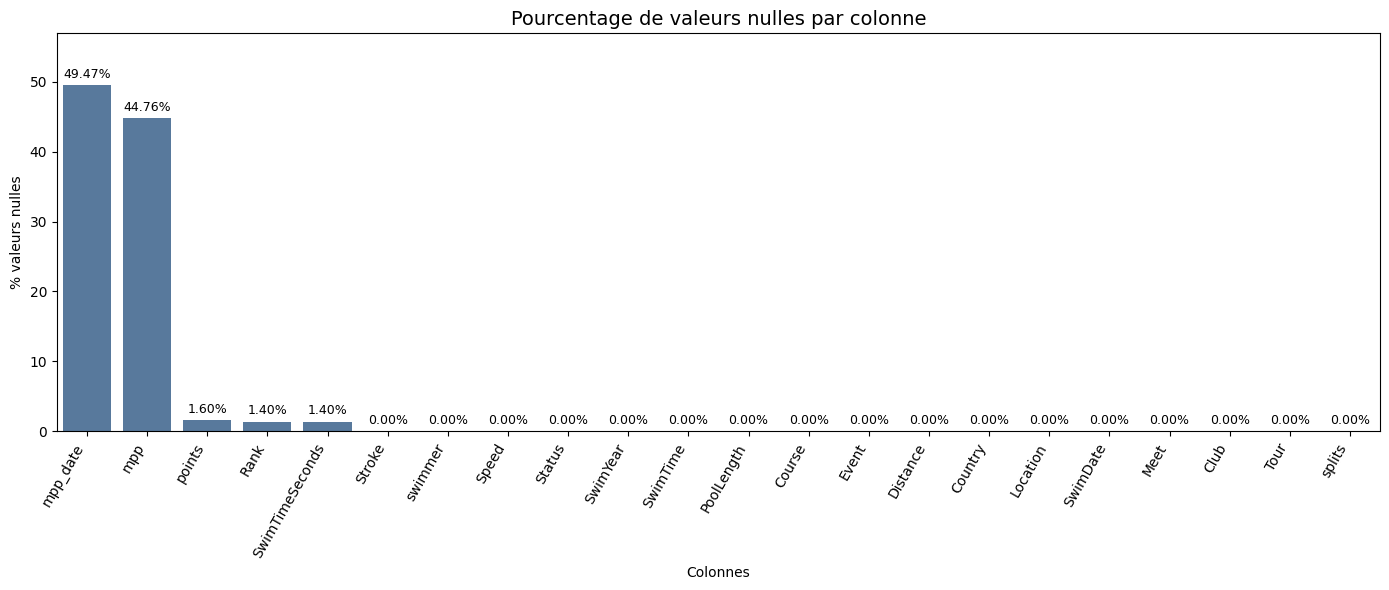

In [31]:
cols_to_check = [
    "Meet", "SwimDate", "Location", "Country", "Event", "Distance",
    "Stroke", "Course", "PoolLength", "Tour", "Rank", "Club", "points",
    "mpp", "mpp_date", "SwimTime", "SwimYear", "SwimTimeSeconds", "Status",
    "Speed", "swimmer", "splits"
]

missing_in_df = [c for c in cols_to_check if c not in df.columns]
if missing_in_df:
    print("Colonnes absentes dans df :", missing_in_df)

cols_present = [c for c in cols_to_check if c in df.columns]

n = len(df)
rows = []

for col in cols_present:
    s = df[col]
    null_mask = s.isna()
    empty_mask = s.map(lambda x: isinstance(x, str) and x.strip() == "")
    invalid_mask = null_mask | empty_mask

    nb_null = int(null_mask.sum())
    nb_empty = int(empty_mask.sum())
    nb_invalid = int(invalid_mask.sum())
    nb_valid = n - nb_invalid

    rows.append({
        "Column": col,
        "Total": n,
        "Null_count": nb_null,
        "Null_%": round((nb_null / n) * 100, 2) if n else 0,
        "Empty_string_count": nb_empty,
        "Empty_string_%": round((nb_empty / n) * 100, 2) if n else 0,
        "Null_or_empty_count": nb_invalid,
        "Null_or_empty_%": round((nb_invalid / n) * 100, 2) if n else 0,
        "Valid_count": nb_valid,
        "Valid_%": round((nb_valid / n) * 100, 2) if n else 0,
    })

quality_table = pd.DataFrame(rows).sort_values(
    by=["Null_or_empty_count", "Null_count", "Empty_string_count"],
    ascending=False
).reset_index(drop=True)

display(quality_table)

global_summary = pd.DataFrame([{
    "Total_rows": n,
    "Checked_columns": len(cols_present),
    "Columns_with_issues": int((quality_table["Null_or_empty_count"] > 0).sum()),
    "Columns_without_issues": int((quality_table["Null_or_empty_count"] == 0).sum()),
}])

display(global_summary)

plot_df = quality_table.copy().sort_values("Null_%", ascending=False)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=plot_df, x="Column", y="Null_%", color="#4C78A8")

plt.title("Pourcentage de valeurs nulles par colonne", fontsize=14)
plt.xlabel("Colonnes")
plt.ylabel("% valeurs nulles")
plt.xticks(rotation=60, ha="right")
plt.ylim(0, max(5, plot_df["Null_%"].max() * 1.15))

# Afficher la valeur sur chaque barre
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.2f}%",
                (p.get_x() + p.get_width() / 2, h),
                ha="center", va="bottom", fontsize=9, xytext=(0, 3),
                textcoords="offset points")

plt.tight_layout()
plt.show()

<h2 style="color:gray; font-size:20px;">SwimYear</h2>

In [32]:
from datetime import datetime
swimyear_num = pd.to_numeric(df["SwimYear"], errors="coerce")

annee_actuelle = datetime.now().year

mask_valide = swimyear_num.notna() & (swimyear_num <= annee_actuelle)

df_invalid = df.loc[~mask_valide, ["SwimDate", "SwimYear", "Meet", "Event"]].copy()

print(f"Total lignes               : {len(df)}")
print(f"SwimYear valides           : {mask_valide.sum()} ({mask_valide.mean()*100:.2f}%)")
print(f"SwimYear invalides / vides : {(~mask_valide).sum()} ({(~mask_valide).mean()*100:.2f}%)")

nb_vides = swimyear_num.isna().sum()
nb_futures = (swimyear_num > annee_actuelle).sum()

print(f"- SwimYear vides/non numériques : {nb_vides}")
print(f"- SwimYear > année actuelle     : {nb_futures}")

display(df_invalid.head(20))

Total lignes               : 759459
SwimYear valides           : 759459 (100.00%)
SwimYear invalides / vides : 0 (0.00%)
- SwimYear vides/non numériques : 0
- SwimYear > année actuelle     : 0


,SwimDate,SwimYear,Meet,Event


<h2 style="color:gray; font-size:20px;">Year_of_birth</h2>

In [33]:
df_check = df.explode("swimmer").copy()
df_check = df_check[df_check["swimmer"].apply(lambda x: isinstance(x, dict))]

current_year = pd.Timestamp.today().year
year_of_birth_num = pd.to_numeric(
    df_check["swimmer"].apply(lambda x: x.get("Year_of_birth")),
    errors="coerce"
)

valid_mask = year_of_birth_num.notna() & (year_of_birth_num <= current_year)
invalid_or_future_mask = year_of_birth_num.isna() | (year_of_birth_num > current_year)

total = len(df_check)
nb_valid = int(valid_mask.sum())
nb_invalid_or_future = int(invalid_or_future_mask.sum())

pct_valid = (nb_valid / total * 100) if total else 0
pct_invalid_or_future = (nb_invalid_or_future / total * 100) if total else 0

print(f"Total lignes                                        : {total}")
print(f"Year_of_birth valides                               : {nb_valid} ({pct_valid:.5f}%)")
print(f"Year_of_birth non valides ou superieure a la date actuelle : {nb_invalid_or_future} ({pct_invalid_or_future:.5f}%)")

Total lignes                                        : 887780
Year_of_birth valides                               : 887780 (100.00000%)
Year_of_birth non valides ou superieure a la date actuelle : 0 (0.00000%)


<h2 style="color:gray; font-size:20px;">Stroke</h2>

In [34]:
print(df['Stroke'].unique()) 

['FR' 'BK' 'BR' 'FL' 'MD']


<h2 style="color:gray; font-size:20px;">Distance</h2>

In [35]:
print(df["Distance"].sort_values(ascending=True).unique()) 

[  25   50  100  200  400  500  800 1000 1200 1500]


<h2 style="color:gray; font-size:20px;">Event</h2>

In [38]:
print("Les event disponibles sont :")
print(df["Event"].unique()) 
print("Le nombre de event disponibles :",len(df["Event"].unique()))

Les event disponibles sont :
['200 FR SCM' '400 FR SCM' '50 BK SCM' '200 BK SCM' '50 BR SCM'
 '200 BR SCM' '50 FL SCM' '200 FL SCM' '200 MD SCM' '400 MD SCM'
 '500 FR SCM' '1000 FR SCM' '100 FR SCM' '100 BK SCM' '100 BR SCM'
 '100 FL SCM' '800 FR SCM' '50 FR SCM' '1500 FR SCM' '100 MD SCM'
 '50 FR LCM' '100 FR LCM' '200 FR LCM' '400 FR LCM' '800 FR LCM'
 '50 BK LCM' '100 BK LCM' '200 BK LCM' '50 BR LCM' '100 BR LCM'
 '200 BR LCM' '50 FL LCM' '100 FL LCM' '200 FL LCM' '200 MD LCM'
 '400 MD LCM' '1500 FR LCM' '25 BR SCM' '25 FR SCM' '25 BK SCM'
 '25 FL SCM' '1200 FR LCM' '500 FR LCM' '1000 FR LCM']
Le nombre de event disponibles : 44


<h2 style="color:gray; font-size:20px;">SwimTimeSeconds</h2>

In [65]:
total_lignes = len(df)

nb_null = df['SwimTimeSeconds'].isna().sum()
pourcentage_null = (nb_null / total_lignes) * 100

nb_empty = (df['SwimTimeSeconds'] == "").sum()
pourcentage_empty = (nb_empty / total_lignes) * 100

print(f"Nombre de SwimTimeSeconds nulles (NaN) : {nb_null} ({pourcentage_null:.2f}%)")
print(f"Nombre de SwimTimeSeconds vides ('') : {nb_empty} ({pourcentage_empty:.2f}%)")

Nombre de SwimTimeSeconds nulles (NaN) : 10596 (1.40%)
Nombre de SwimTimeSeconds vides ('') : 0 (0.00%)


In [ ]:
def get_split_seconds_list(splits):
    vals = []
    if not (isinstance(splits, list) and len(splits) > 0):
        return vals
    for s in splits:
        if not isinstance(s, dict):
            continue
        v = s.get("split_seconds")
        if v is None:
            continue
        try:
            vals.append(float(v))
        except Exception:
            continue
    return vals

split_secs_per_perf = df["splits"].apply(get_split_seconds_list)

mask_with_splits = split_secs_per_perf.apply(lambda L: len(L) > 0)
nb_perf_with_splits = int(mask_with_splits.sum())

mask_perf_lt_20 = split_secs_per_perf.apply(lambda L: len(L) > 0 and any(x < 20 for x in L))
mask_perf_gt_120 = split_secs_per_perf.apply(lambda L: len(L) > 0 and any(x > 120 for x in L))
mask_perf_both = split_secs_per_perf.apply(lambda L: len(L) > 0 and any(x < 20 for x in L) and any(x > 120 for x in L))

nb_perf_lt_20 = int(mask_perf_lt_20.sum())
nb_perf_gt_120 = int(mask_perf_gt_120.sum())
nb_perf_both = int(mask_perf_both.sum())

pct_perf_with_splits = (nb_perf_with_splits / len(df) * 100) if len(df) else 0

# % des cas <20, >120, both parmi les performances exploitables
pct_perf_lt_20 = (nb_perf_lt_20 / nb_perf_with_splits * 100) if nb_perf_with_splits else 0
pct_perf_gt_120 = (nb_perf_gt_120 / nb_perf_with_splits * 100) if nb_perf_with_splits else 0
pct_perf_both = (nb_perf_both / nb_perf_with_splits * 100) if nb_perf_with_splits else 0

print(f"Performances totales                  : {len(df)}")
print(f"Performances avec splits exploitables : {nb_perf_with_splits} ({pct_perf_with_splits:.2f}%)")
print(f"Perf avec >=1 split_seconds < 20 sec  : {nb_perf_lt_20} ({pct_perf_lt_20:.2f}%)")
print(f"Perf avec >=1 split_seconds > 120 sec : {nb_perf_gt_120} ({pct_perf_gt_120:.2f}%)")
print(f"Perf avec les deux conditions         : {nb_perf_both} ({pct_perf_both:.2f}%)")

Performances totales                  : 759459
Performances avec splits exploitables : 499961 (65.83%)
Perf avec >=1 split_seconds < 20 sec  : 0 (0.00%)
Perf avec >=1 split_seconds > 120 sec : 0 (0.00%)
Perf avec les deux conditions         : 0 (0.00%)


<h2 style="color:gray; font-size:20px;">Swimmer</h2>

In [51]:
df['swimmer_name'] = df['swimmer'].apply(
    lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else None
)

participations = df.groupby(['swimmer_name', 'Event']).size().reset_index(name='count')

max_count = participations['count'].max()

max_participations = participations[participations['count'] == max_count]

print("Le nageur ayant le nombre de performances le plus élevé est :")
print(max_participations[['swimmer_name', 'Event', 'count']])

Le nageur ayant le nombre de performances le plus élevé est :
           swimmer_name      Event  count
128652  Henique Mélanie  50 FL LCM    144


In [ ]:
nom_event = "400 MD LCM"

df['swimmer_name'] = df['swimmer'].apply(
    lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else None
)

df_filtered = df[df['swimmer_name'].notna()]

total_participations = (
    df_filtered[df_filtered['Event'] == nom_event]
    .groupby('swimmer_name')
    .size()
    .reset_index(name='total_participations')
)

valid_performances = (
    df_filtered[(df_filtered['Event'] == nom_event) & df_filtered['SwimTimeSeconds'].notna()]
    .groupby('swimmer_name')
    .size()
    .reset_index(name='valid_performances')
)

top_swimmers = pd.merge(total_participations, valid_performances, on='swimmer_name', how='left')

top_swimmers = top_swimmers.sort_values(by='total_participations', ascending=False).head(10)

top_swimmers['valid_performances'] = top_swimmers['valid_performances'].fillna(0).astype(int)
top_swimmers['total_participations'] = top_swimmers['total_participations'].astype(int)

top_swimmers = top_swimmers.rename(columns={
    'swimmer_name': 'Nom des nageurs',
    'total_participations': 'Total performances',
    'valid_performances': 'Total performances valides'
})

print("Les nageurs qui ont le nombre de performances le plus élevé pour le event", nom_event, " :")
print(top_swimmers)

Les nageurs qui ont le nombre de performances le plus élevé pour le event 400 MD LCM  :
               Nom des nageurs  Total performances  Total performances valides
6338           Renard Geoffrey                  72                          72
4479          Lesaffre Fantine                  69                          67
3110  Grangeon-De Villele Lara                  66                          65
7662           Verraszto David                  66                          66
4982          Mattenet Emilien                  66                          66
3526            Hosszu Katinka                  58                          58
7340         Tissandie Camille                  57                          57
7169              Syoud Jaouad                  54                          54
2304          Duhamel Cyrielle                  53                          53
3166                Gruart Leo                  53                          53


<h2 style="color:gray; font-size:20px;">Split</h2>

In [103]:
df_check = df[["Meet", "Event", "Distance", "splits"]].copy()
df_check["Distance_num"] = pd.to_numeric(df_check["Distance"], errors="coerce")

mask_has_splits = df_check["splits"].apply(lambda x: isinstance(x, list) and len(x) > 0)
df_with_splits = df_check[mask_has_splits & df_check["Distance_num"].notna()].copy()

def get_last_split_distance(splits):
    last = splits[-1]
    if not isinstance(last, dict):
        return None
    raw = last.get("split_distance")
    if raw is None:
        return None
    try:
        return float(str(raw).replace("m", "").strip())
    except Exception:
        return None

df_with_splits["LastSplitDistance"] = df_with_splits["splits"].apply(get_last_split_distance)

tol = 1e-9
mask_valid_last = df_with_splits["LastSplitDistance"].notna()
mask_inferieur = mask_valid_last & (df_with_splits["LastSplitDistance"] < df_with_splits["Distance_num"])
mask_egal = mask_valid_last & ((df_with_splits["LastSplitDistance"] - df_with_splits["Distance_num"]).abs() <= tol)

nb_total_with_splits = len(df_with_splits)
nb_last_valid = int(mask_valid_last.sum())

nb_inferieur = int(mask_inferieur.sum())
pct_inferieur = (nb_inferieur / nb_total_with_splits * 100) if nb_total_with_splits else 0

nb_egal = int(mask_egal.sum())
pct_egal = (nb_egal / nb_total_with_splits * 100) if nb_total_with_splits else 0

print(f"Performances avec splits (Distance valide) : {nb_total_with_splits}")
print(f"Performances avec dernier split exploitable: {nb_last_valid}")
print(f"Dernier split < Distance                   : {nb_inferieur} ({pct_inferieur:.2f}%)")
print(f"Dernier split = Distance                   : {nb_egal} ({pct_egal:.2f}%)")

top_meets_problem = (
    df_with_splits.loc[mask_inferieur, "Meet"]
    .dropna()
    .astype(str)
    .value_counts()
    .head(5)
)

print("\nTop 5 meets où dernier split < Distance :")
for meet, n in top_meets_problem.items():
    print(f"- {meet} : {n} performances")

top_meet_event_problem = (
    df_with_splits.loc[mask_inferieur, ["Meet", "Event"]]
    .dropna(subset=["Meet", "Event"])
    .astype(str)
    .value_counts()
    .reset_index(name="nb_performances")
    .head(5)
)

print("\nTop 5 couples (Meet, Event) où dernier split < Distance :")
for _, row in top_meet_event_problem.iterrows():
    print(f"- {row['Meet']} | {row['Event']} : {row['nb_performances']} performances")

Performances avec splits (Distance valide) : 499961
Performances avec dernier split exploitable: 499961
Dernier split < Distance                   : 25363 (5.07%)
Dernier split = Distance                   : 474598 (94.93%)

Top 5 meets où dernier split < Distance :
- Championnats du Monde en grand bassin : 2137 performances
- Championnats de France Elite : 1880 performances
- Championnats de France en petit bassin : 1615 performances
- Championnats d'Europe Juniors : 1437 performances
- Championnats d'Europe en grand bassin : 1278 performances

Top 5 couples (Meet, Event) où dernier split < Distance :
- Championnats du Monde en grand bassin | 800 FR LCM : 1388 performances
- Championnats de France Elite | 800 FR LCM : 1053 performances
- Championnats d'Europe Juniors | 800 FR LCM : 965 performances
- Championnats de France en petit bassin | 800 FR SCM : 935 performances
- Championnats de France Elite | 1500 FR LCM : 827 performances


In [127]:
nb_total = len(df)

def has_nonempty_splits(x):
    return isinstance(x, list) and len(x) > 0

mask_splits = df["splits"].apply(has_nonempty_splits)
nb_avec_splits = int(mask_splits.sum())
pct_avec_splits_total = (nb_avec_splits / nb_total * 100) if nb_total else 0

df_s = df.loc[mask_splits]

def swimmer_len(x):
    if isinstance(x, list):
        return len(x)
    return None  

df_s = df_s.copy()
df_s["_swimmer_len"] = df_s["swimmer"].apply(swimmer_len)

mask_1_swimmer = df_s["_swimmer_len"] == 1
mask_plusieurs_swimmers = df_s["_swimmer_len"].notna() & (df_s["_swimmer_len"] > 1)
mask_swimmer_invalide = df_s["_swimmer_len"].isna() | (df_s["_swimmer_len"] == 0)

nb_1_swimmer = int(mask_1_swimmer.sum())
nb_plusieurs = int(mask_plusieurs_swimmers.sum())
nb_swimmer_bizarre = int(mask_swimmer_invalide.sum())

pct_1_swimmer_total = (nb_1_swimmer / nb_total * 100) if nb_total else 0
pct_plusieurs_total = (nb_plusieurs / nb_total * 100) if nb_total else 0

base = nb_avec_splits
pct_1_swimmer_sur_splits = (nb_1_swimmer / base * 100) if base else 0
pct_plusieurs_sur_splits = (nb_plusieurs / base * 100) if base else 0
pct_bizarre_sur_splits = (nb_swimmer_bizarre / base * 100) if base else 0

print(f"Total performances                              : {nb_total}")
print(f"Avec au moins 1 split                           : {nb_avec_splits} ({pct_avec_splits_total:.2f}% du total)")
print()
print("Parmi les performances avec splits :")
print(f"  - swimmer liste de longueur 1                 : {nb_1_swimmer} ({pct_1_swimmer_sur_splits:.2f}% des perfs avec splits)")
print(f"  - swimmer liste longueur > 1                  : {nb_plusieurs} ({pct_plusieurs_sur_splits:.2f}% des perfs avec splits)")
print(f"  - swimmer absent / pas liste / liste vide     : {nb_swimmer_bizarre} ({pct_bizarre_sur_splits:.2f}% des perfs avec splits)")
print()
print("Pour comparaison (par rapport au total toutes perfs) :")
print(f"  - avec splits + exactement 1 swimmer                     : {nb_1_swimmer} ({pct_1_swimmer_total:.2f}% du total)")
print(f"  - avec splits + plusieurs swimmers (en relais)           : {nb_plusieurs} ({pct_plusieurs_total:.2f}% du total)")

Total performances                              : 759459
Avec au moins 1 split                           : 499961 (65.83% du total)

Parmi les performances avec splits :
  - swimmer liste de longueur 1                 : 466134 (93.23% des perfs avec splits)
  - swimmer liste longueur > 1                  : 33827 (6.77% des perfs avec splits)
  - swimmer absent / pas liste / liste vide     : 0 (0.00% des perfs avec splits)

Pour comparaison (par rapport au total toutes perfs) :
  - avec splits + exactement 1 swimmer                     : 466134 (61.38% du total)
  - avec splits + plusieurs swimmers (en relais)           : 33827 (4.45% du total)


<h1 style="color:rgb(242, 176, 235); font-size:32px;">Distributions de temps</h1>

<h2 style="color:gray; font-size:20px;">Histogram of swim times</h2>

Nombre de performances pour l'event 100 FR LCM: 49722


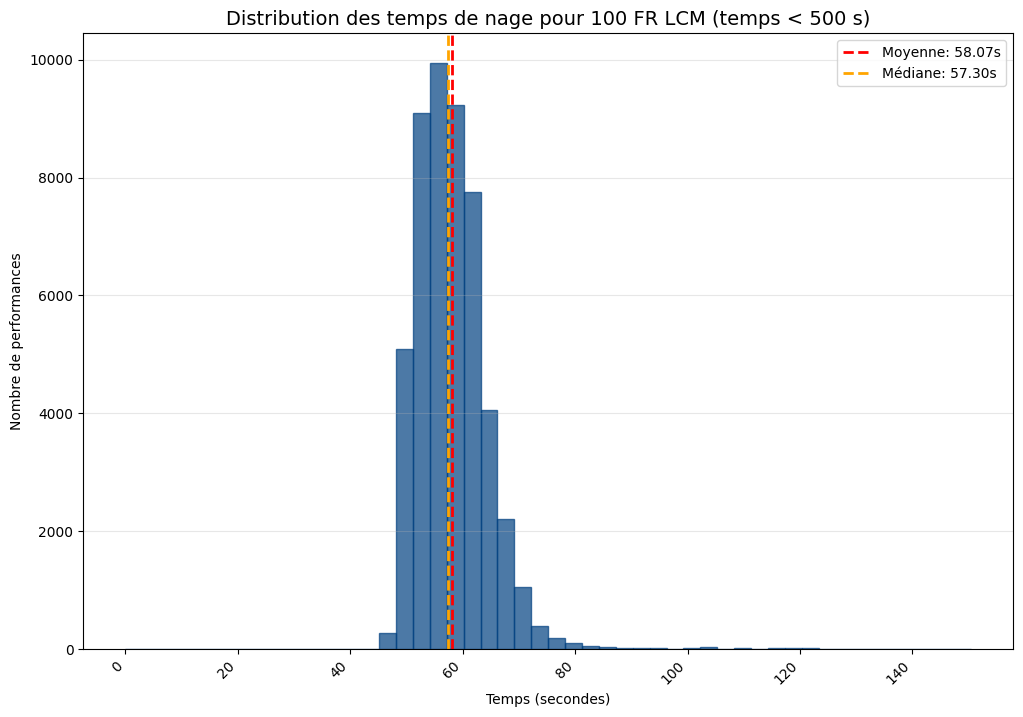

In [10]:
from matplotlib.ticker import MaxNLocator

nom_event = "100 FR LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) & 
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
].dropna()

print(f"Nombre de performances pour l'event {nom_event}: {len(swim_times)}")

fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(swim_times, bins=50, color="#004080", edgecolor="#004080", alpha=0.7)

mean_time = np.mean(swim_times)
median_time = np.median(swim_times)

ax.axvline(mean_time, color='red', linestyle='dashed', linewidth=2,
           label=f'Moyenne: {mean_time:.2f}s')
ax.axvline(median_time, color='orange', linestyle='dashed', linewidth=2,
           label=f'Médiane: {median_time:.2f}s')

ax.set_title(f"Distribution des temps de nage pour {nom_event} (temps < 500 s)", fontsize=14)
ax.set_xlabel("Temps (secondes)")
ax.set_ylabel("Nombre de performances")
ax.legend()

ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.show()

<h2 style="color:gray; font-size:20px;">Histogram with Kernel Density Estimate (KDE)</h2>

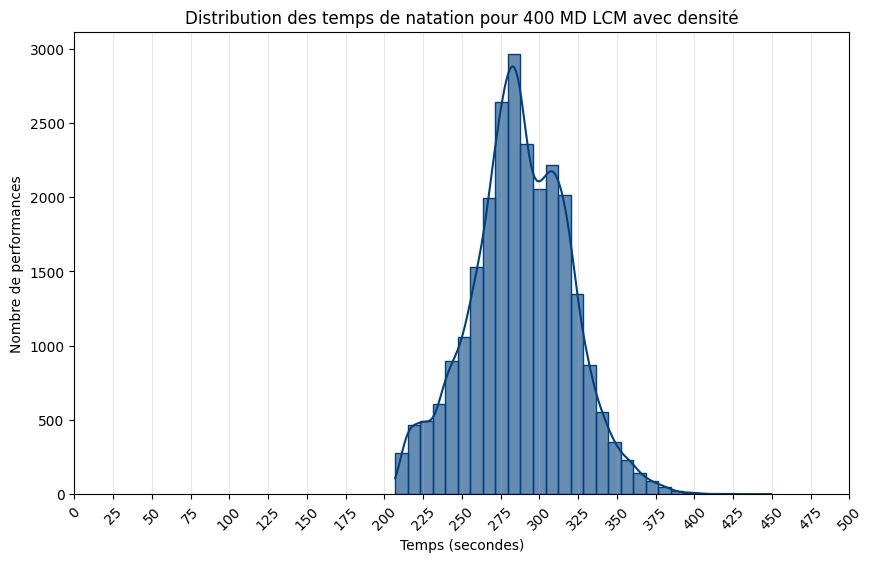

In [10]:
nom_event = "400 MD LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) & 
    (df["SwimTimeSeconds"].notna()) & 
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
]

plt.figure(figsize=(10,6))

sns.histplot(
    swim_times,
    bins=30,
    kde=True,
    color="#004080",
    edgecolor="#004080",
    alpha=0.6
)

plt.title(f"Distribution des temps de natation pour {nom_event} avec densité")
plt.xlabel("Temps (secondes)")
plt.ylabel("Nombre de performances")

plt.xticks(np.arange(0, 501, 25), rotation=45)
plt.grid(axis="x", alpha=0.3)

plt.show()

<h2 style="color:gray; font-size:20px;">Cumulative Histogram</h2>

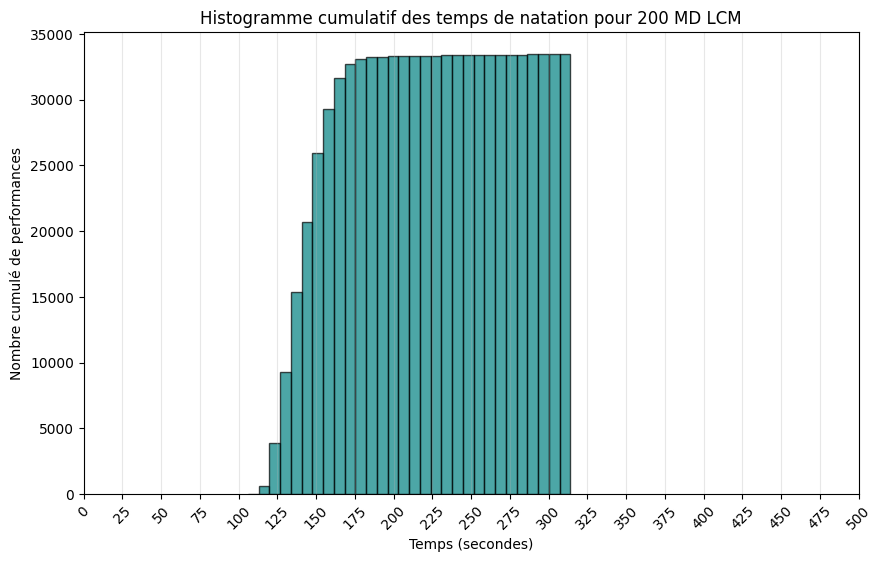

In [11]:
nom_event = "200 MD LCM"

swim_times = df.loc[
    (df["Event"] == nom_event) &
    (df["SwimTimeSeconds"].notna()) &
    (df["SwimTimeSeconds"] < 500),
    "SwimTimeSeconds"
]

if len(swim_times) > 0:
    plt.figure(figsize=(10,6))

    plt.hist(
        swim_times,
        bins=30,
        cumulative=True,
        color="#008080",
        edgecolor="black",
        alpha=0.7
    )

    plt.title(f"Histogramme cumulatif des temps de natation pour {nom_event}")
    plt.xlabel("Temps (secondes)")
    plt.ylabel("Nombre cumulé de performances")

    plt.xticks(np.arange(0, 501, 25), rotation=45)
    plt.grid(axis="x", alpha=0.3)

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Effectifs et répartition par sexe</h1>

<h2 style="color:gray; font-size:20px;">Bar Chart of Total Performances by Event and Gender</h2>

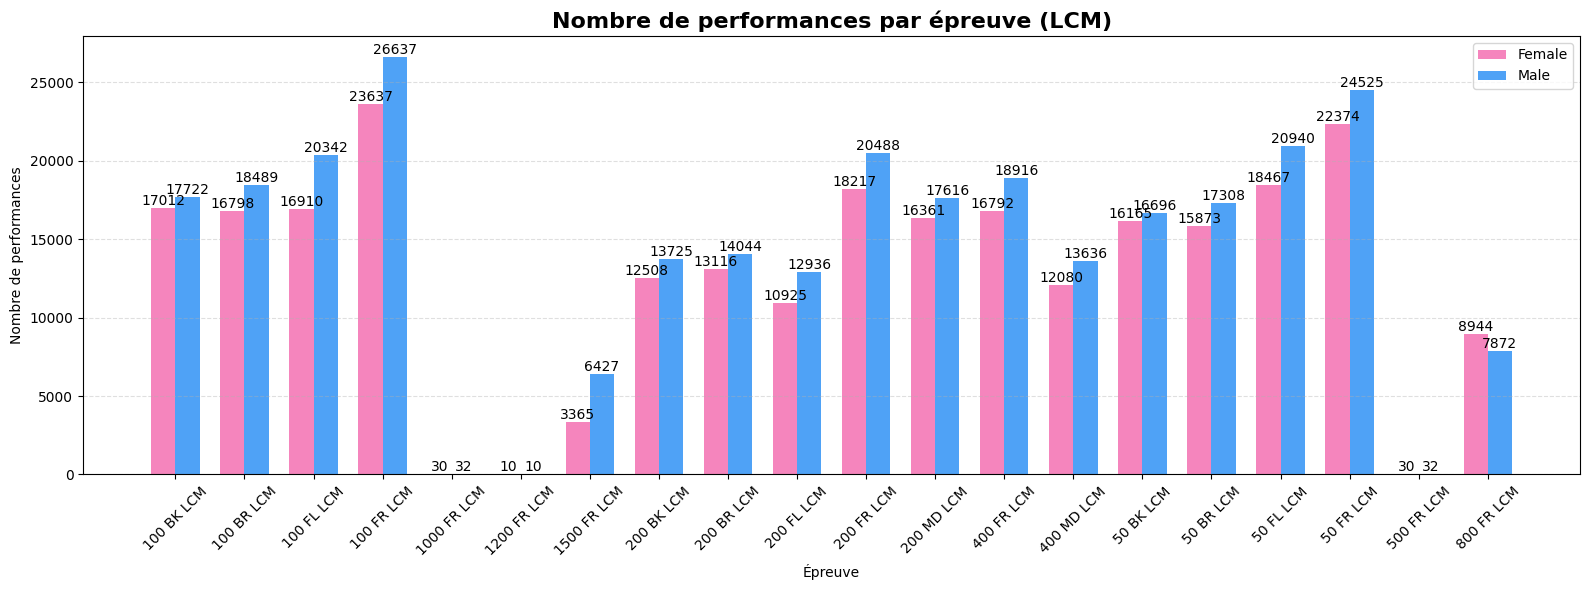

In [13]:
course_type = "LCM"

df["Gender"] = df["swimmer"].apply(
    lambda x: x[0].get("Gender") if isinstance(x, list) and len(x) > 0 else None
)

df["swimmer_name"] = df["swimmer"].apply(
    lambda x: x[0].get("Name") if isinstance(x, list) and len(x) > 0 else None
)

df_clean = df.dropna(subset=["Gender", "Event", "swimmer_name"])

df_clean = df_clean[df_clean["Event"].str.contains(course_type, na=False)]

df_counts = (
    df_clean
    .groupby(["Event", "Gender"])["swimmer_name"]
    .count()
    .unstack(fill_value=0)
    .sort_index()
)

events = df_counts.index

female_counts = df_counts["F"] if "F" in df_counts else pd.Series(0, index=events)
male_counts = df_counts["M"] if "M" in df_counts else pd.Series(0, index=events)

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(16, 6))

bars1 = plt.bar(
    x - width/2, female_counts, width,
    label="Female", color="#F585BD"
)

bars2 = plt.bar(
    x + width/2, male_counts, width,
    label="Male", color="#4FA2F6"
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.1,
            f"{int(height)}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title(
    f"Nombre de performances par épreuve ({course_type})",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Épreuve")
plt.ylabel("Nombre de performances")

plt.xticks(x, events, rotation=45)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

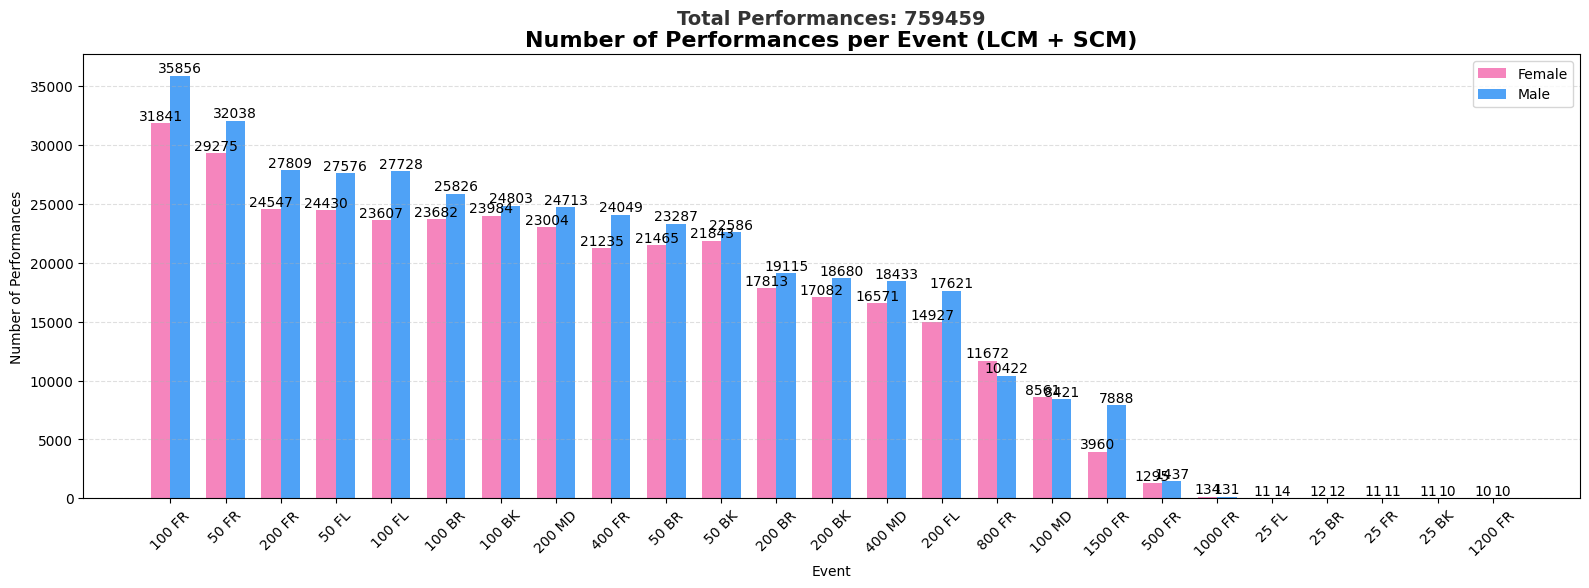

In [11]:
df["Gender"] = df["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

df["Event_clean"] = df["Event"].str.replace(" LCM", "", regex=False)\
                               .str.replace(" SCM", "", regex=False)

df_clean = df.dropna(subset=["Gender", "Event_clean"])

df_counts = (
    df_clean
    .groupby(["Event_clean", "Gender"])
    .size()
    .unstack(fill_value=0)
)

df_counts["Total"] = df_counts.sum(axis=1)
df_counts = df_counts.sort_values("Total", ascending=False).drop(columns="Total")

total_performances = df_counts.sum().sum()

events = df_counts.index
female_counts = df_counts.get("F", [0]*len(events))
male_counts = df_counts.get("M", [0]*len(events))

x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(16,6))

bars1 = plt.bar(x - width/2, female_counts, width, 
                label="Female", color="#F585BD")

bars2 = plt.bar(x + width/2, male_counts, width, 
                label="Male", color="#4FA2F6")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.1,
            f"{int(height)}",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title("Number of Performances per Event (LCM + SCM)", fontsize=16, fontweight="bold")

plt.text(
    0.5, 1.08,
    f"Total Performances: {int(total_performances)}",
    ha='center',
    va='center',
    transform=plt.gca().transAxes,
    fontsize=14,
    fontweight='bold',
    color="#333333"
)

plt.xlabel("Event")
plt.ylabel("Number of Performances")
plt.xticks(x, events, rotation=45)
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

<h2 style="color:gray; font-size:20px;">Countplot total number of performances by sex</h2>

Gender
M    399828
F    362543
Name: count, dtype: int64


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_3393/3315299978.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette=palette_colors)


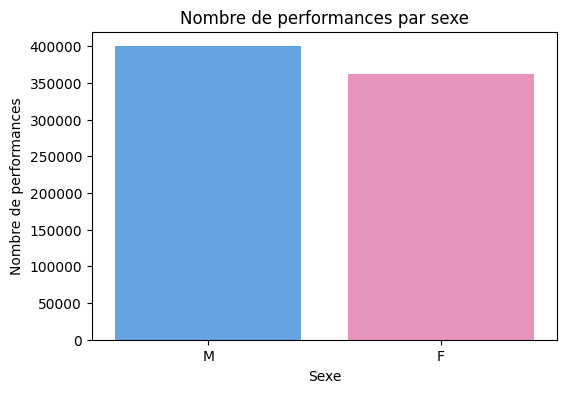

In [14]:
df["Gender"] = df["swimmer"].apply(lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None)

print(df["Gender"].value_counts())

plt.figure(figsize=(6,4))

palette_colors = {
    "F": "#F585BD",
    "M": "#4FA2F6"
}

sns.countplot(x="Gender", data=df, palette=palette_colors)

plt.title("Nombre de performances par sexe")
plt.xlabel("Sexe")
plt.ylabel("Nombre de performances")

plt.show()

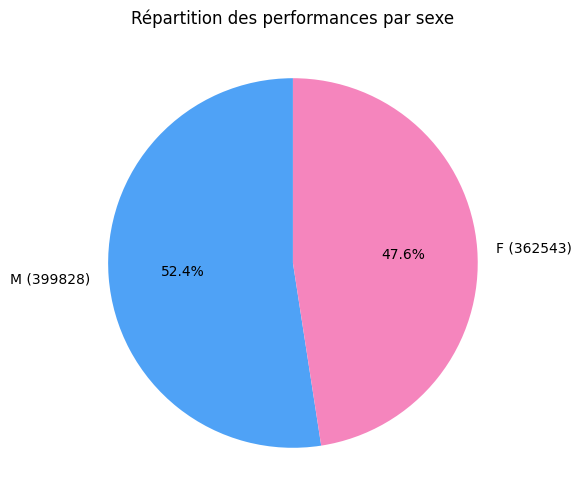

In [31]:
gender_counts = df["Gender"].value_counts()

colors = ["#4FA2F6","#F585BD"]

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=[f"{g} ({n})" for g, n in zip(gender_counts.index, gender_counts)],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Répartition des performances par sexe")

plt.show()

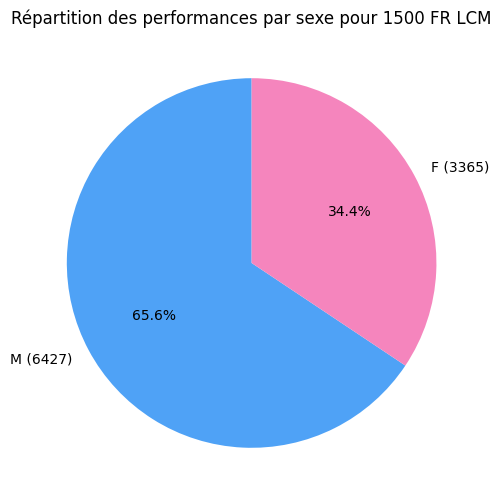

In [33]:
nom_event = "1500 FR LCM"

df_event = df[df["Event"] == nom_event].copy()

df_event["Gender"] = df_event["swimmer"].apply(
    lambda x: x[0]["Gender"] if isinstance(x, list) and len(x) > 0 else None
)

gender_counts = df_event["Gender"].value_counts()

if len(gender_counts) > 0:
    colors = ["#4FA2F6", "#F585BD"]

    plt.figure(figsize=(6,6))

    plt.pie(
        gender_counts,
        labels=[f"{g} ({n})" for g, n in zip(gender_counts.index, gender_counts)],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90
    )

    plt.title(f"Répartition des performances par sexe pour {nom_event}")
    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Distribution des temps par nage</h1>

<h2 style="color:gray; font-size:20px;">Boxplot (Boite à moustaches) du temps par stroke et la distance</h2>

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2087/1248598205.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


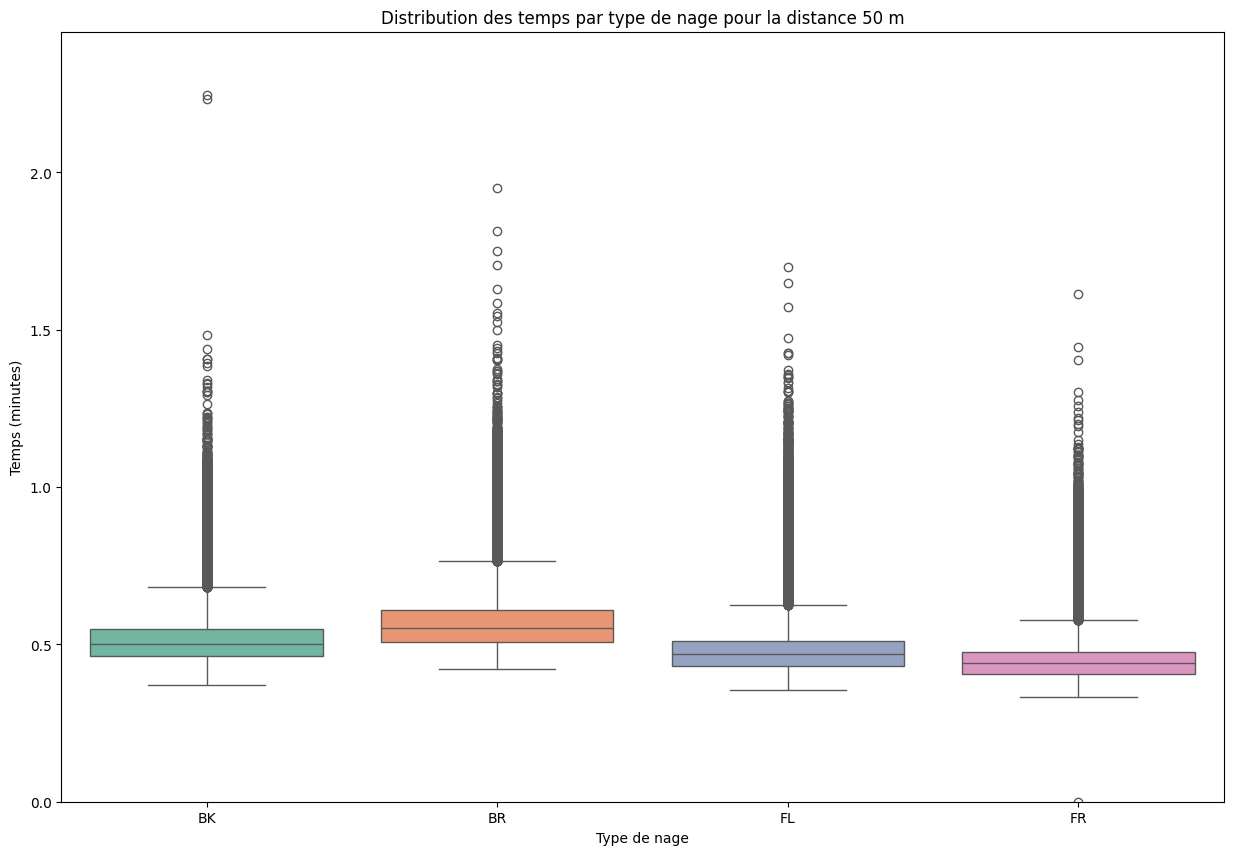

In [70]:
distance_choisie = 50

subset = df[
    (df["SwimTimeSeconds"].notna()) &
    (df["Distance"] == distance_choisie)
].copy()

if len(subset) > 0:
    subset["SwimTimeMinutes"] = subset["SwimTimeSeconds"] / 60

    plt.figure(figsize=(15, 10))
    sns.boxplot(
        x="Stroke",
        y="SwimTimeMinutes",
        data=subset,
        palette="Set2"
    )

    plt.title(f"Distribution des temps par type de nage pour la distance {distance_choisie} m")
    plt.xlabel("Type de nage")
    plt.ylabel("Temps (minutes)")
    plt.ylim(0, subset["SwimTimeMinutes"].max() + 0.2)

    plt.show()
else:
    print(f"Aucune donnée disponible pour la distance {distance_choisie} m")

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Clubs</h1>

<h2 style="color:gray; font-size:20px;">Bar Chart of Number of Performances per Club</h2>

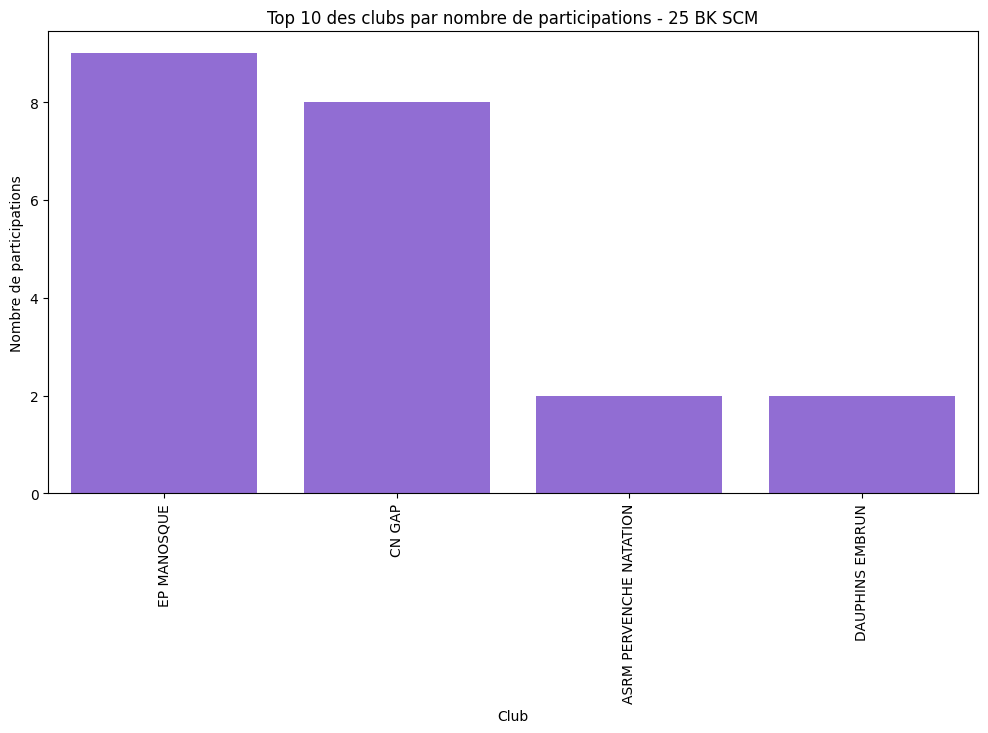

In [5]:
nom_event = "25 BK SCM"

df_event = df[df["Event"] == nom_event]

top_clubs = df_event["Club"].value_counts().nlargest(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_clubs.index, y=top_clubs.values, color="#8C5CE4")

plt.title(f"Top 10 des clubs par nombre de participations - {nom_event}")
plt.xlabel("Club")
plt.ylabel("Nombre de participations")
plt.xticks(rotation=90)

plt.show()

In [7]:
nom_event = "25 BK SCM"

clubs = (
    df[df["Event"] == nom_event]["Club"]
    .dropna()
    .unique()
)

print("Clubs participants :")
print(clubs)

Clubs participants :
['ASRM PERVENCHE NATATION' 'CN GAP' 'EP MANOSQUE' 'DAUPHINS EMBRUN']


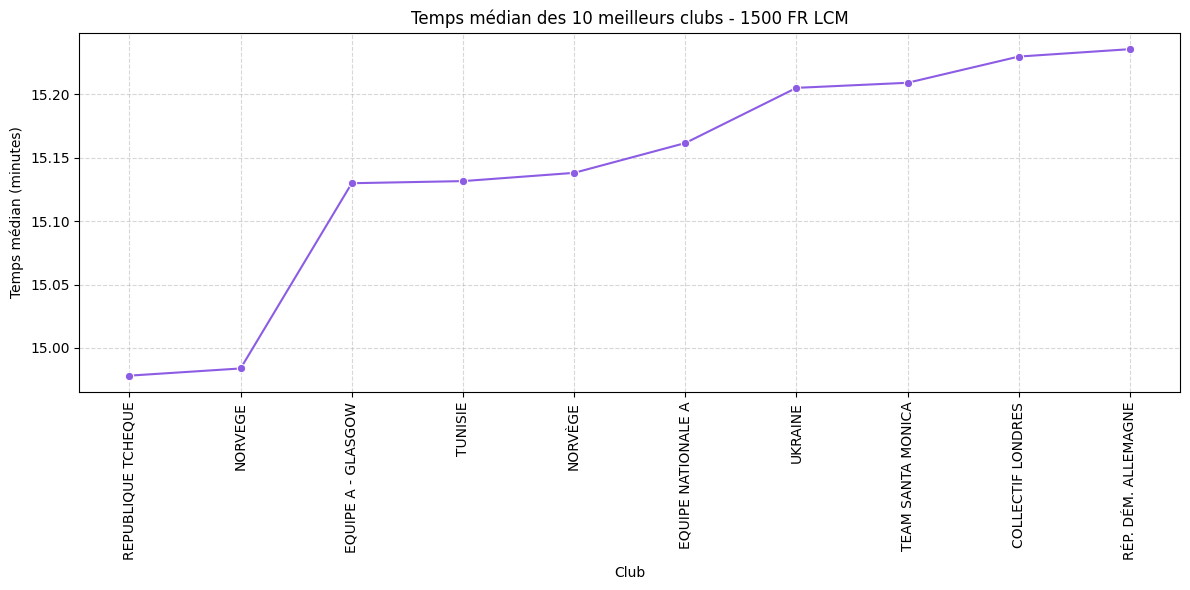

,Club,SwimTimeMinutes
508,REPUBLIQUE TCHEQUE,14.978167
466,NORVEGE,14.983833
292,EQUIPE A - GLASGOW,15.129833
610,TUNISIE,15.131500
467,NORVÈGE,15.138000
295,EQUIPE NATIONALE A,15.161500
613,UKRAINE,15.205000
599,TEAM SANTA MONICA,15.209000
240,COLLECTIF LONDRES,15.229667
514,RÉP. DÉM. ALLEMAGNE,15.235500


In [103]:
nom_event = "1500 FR LCM"

df_time = df[
    (df["Event"] == nom_event)
    & (df["SwimTimeSeconds"].notna())
].copy()

df_time["SwimTimeMinutes"] = df_time["SwimTimeSeconds"] / 60

median_time_club = (
    df_time.groupby("Club", dropna=False)["SwimTimeMinutes"]
    .median()
    .reset_index()
    .sort_values("SwimTimeMinutes")
)

top10_clubs = median_time_club.head(10)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=top10_clubs,
    x="Club",
    y="SwimTimeMinutes",
    marker="o",
    color="#8C5CE4"
)

plt.title(f"Temps médian des 10 meilleurs clubs - {nom_event}")
plt.xlabel("Club")
plt.ylabel("Temps médian (minutes)")
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

display(top10_clubs)

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Chronos dans le temps</h1>

<h2 style="color:gray; font-size:20px;">Line Plot of Swim Times by Stroke Type Over Time for a Sample of 5000</h2>

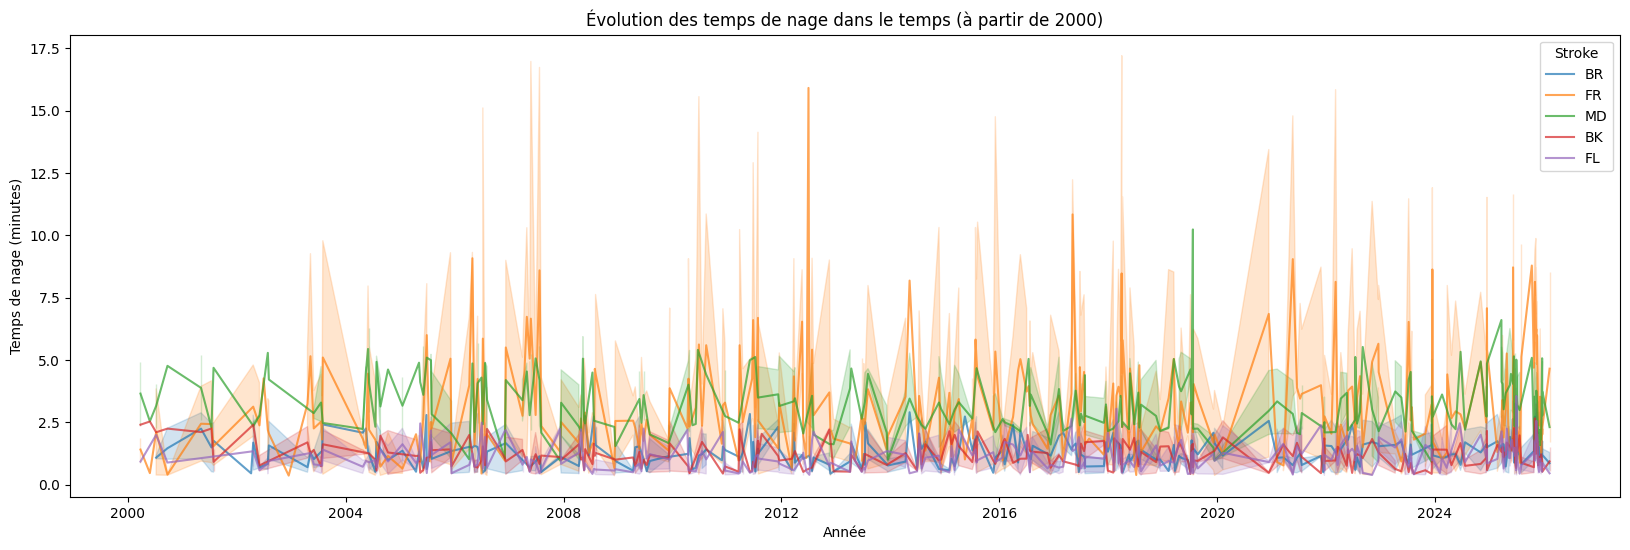

In [7]:
df["SwimDate"] = pd.to_datetime(df["SwimDate"], errors="coerce")

df_plot = df[
    (df["SwimDate"].notna())
    & (df["SwimTimeSeconds"].notna())
    & (df["SwimDate"].dt.year >= 2000)
].copy()

df_plot["SwimTimeMinutes"] = df_plot["SwimTimeSeconds"] / 60

plt.figure(figsize=(20, 6))
sns.lineplot(
    x="SwimDate",
    y="SwimTimeMinutes",
    data=df_plot.sample(min(5000, len(df_plot)), random_state=42),
    hue="Stroke",
    alpha=0.7
)

plt.title("Évolution des temps de nage dans le temps (à partir de 2000)")
plt.xlabel("Année")
plt.ylabel("Temps de nage (minutes)")
plt.legend(title="Stroke")
plt.show()

In [71]:
df['SwimDate'] = pd.to_datetime(df['SwimDate'], errors='coerce')

df['Year'] = df['SwimDate'].dt.year

min_year = df['Year'].min()

print("L'année la plus ancienne est :", min_year)

L'année la plus ancienne est : 1976


/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_2087/2538075256.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


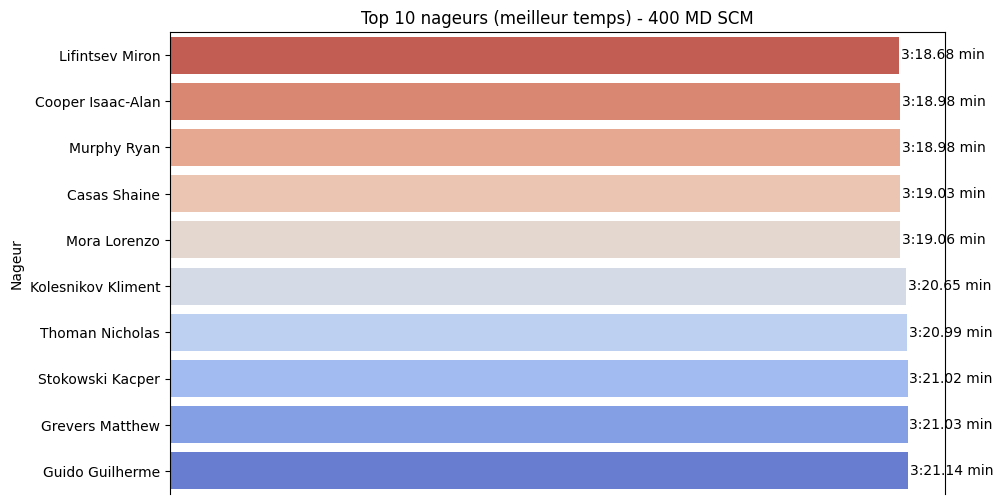

In [73]:
nom_event = "400 MD SCM"

subset = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['SwimTimeSeconds'] > 0)
].copy()

if len(subset) > 0:
    subset['SwimmerName'] = subset['swimmer'].apply(
        lambda x: x[0]['Name'] if isinstance(x, list) and len(x) > 0 else "Unknown"
    )

    best_times = subset.groupby('SwimmerName', as_index=False)['SwimTimeSeconds'].min()

    top10 = best_times.nsmallest(10, 'SwimTimeSeconds')

    def format_time(sec):
        minutes = int(sec // 60)
        seconds = sec % 60
        return f"{minutes}:{seconds:05.2f} min"

    plt.figure(figsize=(10,6))
    ax = sns.barplot(
        x='SwimTimeSeconds',
        y='SwimmerName',
        data=top10,
        palette="coolwarm_r",
        orient='h',
        errorbar=None
    )

    plt.title(f"Top 10 nageurs (meilleur temps) - {nom_event}")
    plt.ylabel("Nageur")

    ax.set_xlabel("")
    ax.set_xticks([])
    ax.spines['bottom'].set_visible(False)

    for i, v in enumerate(top10['SwimTimeSeconds']):
        ax.text(v + 0.5, i, format_time(v), va='center')

    plt.show()
else:
    print(f"Aucune donnée disponible pour l'événement {nom_event}")

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Vitesse globale</h1>

<h2 style="color:gray; font-size:20px;">Lineplot of Speed Performance Across Distances by Stroke</h2>

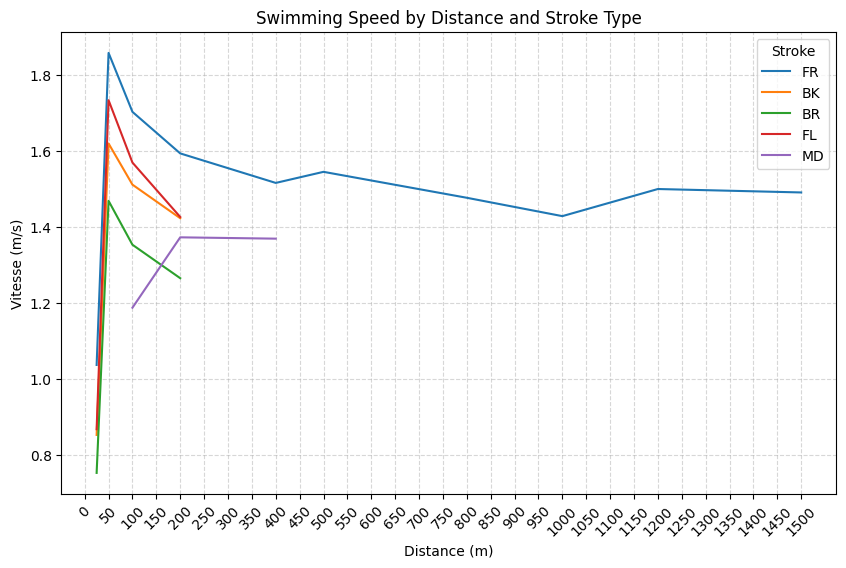

In [55]:
df_speed = df[df['Speed'].notna()]

plt.figure(figsize=(10,6))

sns.lineplot(
    x='Distance',
    y='Speed',
    hue='Stroke',
    data=df_speed,
    errorbar=None
)

max_distance = int(df_speed['Distance'].max())
plt.xticks(np.arange(0, max_distance + 50, 50), rotation=45)

plt.title("Swimming Speed by Distance and Stroke Type")
plt.xlabel("Distance (m)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Max Speed per Split Distance and Stroke:


,Swimmer,Stroke,SplitDistance,SplitSpeed
0,Bazil Gabriel,BK,50,2.452
1,Bastien Thibault,BK,100,2.170
2,Arhab Botko Mathilde,BK,150,2.266
3,Adjesson Aaliyah,BK,200,2.323
4,Tateishi Ryo,BR,50,2.160
5,Karpeeva Svetlana,BR,100,1.937
6,Gyurta Daniel,BR,150,1.620
7,Contrino Gianni,BR,200,2.030
8,Delecluse Theo,FL,50,2.412
9,Soulas Alexis,FL,100,2.285


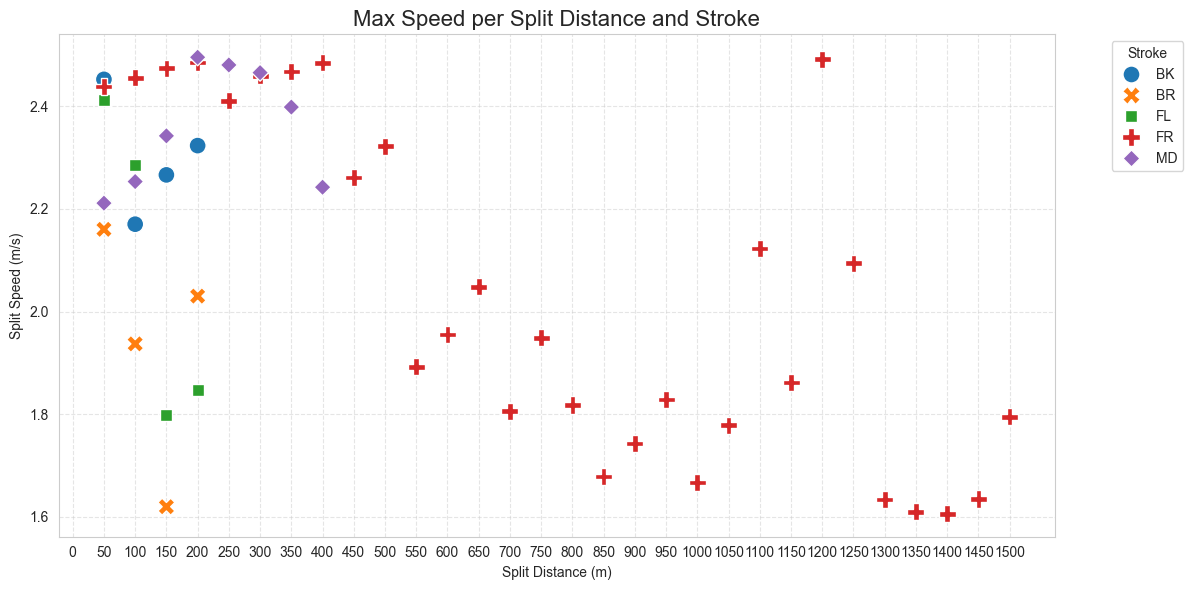

In [9]:
import mplcursors
df_clean = df.loc[df['Speed'].notna(), ['Stroke', 'Distance', 'Speed', 'swimmer', 'splits']].copy()

def clean_swimmer(x):
    if isinstance(x, dict):
        return x.get('Name')
    elif isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict):
        return x[0].get('Name')
    return None

df_clean['Swimmer'] = df_clean['swimmer'].map(clean_swimmer)
df_clean = df_clean.dropna(subset=['Swimmer'])

df_split = []

for _, row in df_clean.loc[df_clean['splits'].apply(lambda x: isinstance(x, list) and len(x) > 0)].iterrows():
    swimmer_name = row['Swimmer']
    stroke = row['Stroke']
    
    for s in row['splits']:
        split_distance = s.get('split_distance')
        split_speed = s.get('split_speed')
        
        if split_distance is not None and split_speed is not None:
            try:
                dist = int(str(split_distance).replace(' m', ''))
                speed = float(split_speed)
                if 0 < speed < 5:
                    df_split.append({
                        'Stroke': stroke,
                        'SplitDistance': dist,
                        'SplitSpeed': speed,
                        'Swimmer': swimmer_name
                    })
            except:
                continue

df_splits = pd.DataFrame(df_split)

df_splits_max = df_splits.loc[
    df_splits.groupby(['Stroke', 'SplitDistance'])['SplitSpeed'].idxmax()
].reset_index(drop=True)

print("Max Speed per Split Distance and Stroke:")
display(df_splits_max[['Swimmer', 'Stroke', 'SplitDistance', 'SplitSpeed']])

plt.figure(figsize=(12,6))
sns.set_style("whitegrid")

ax = sns.scatterplot(
    data=df_splits_max,
    x='SplitDistance',
    y='SplitSpeed',
    hue='Stroke',
    style='Stroke',
    s=150
)

max_split = int(df_splits_max['SplitDistance'].max())
plt.xticks(np.arange(0, max_split + 50, 50))

points = df_splits_max[['SplitDistance', 'SplitSpeed', 'Swimmer', 'Stroke']].values

cursor = mplcursors.cursor(ax.collections, hover=True)

@cursor.connect("add")
def on_add(sel):
    x, y = sel.target
    distances = (points[:, 0] - x)**2 + (points[:, 1] - y)**2
    idx = distances.argmin()
    
    sel.annotation.set_text(
        f"{points[idx][2]}\n"
        f"Stroke: {points[idx][3]}\n"
        f"Split Distance: {int(points[idx][0])} m\n"
        f"Split Speed: {points[idx][1]:.2f} m/s"
    )

plt.title("Max Speed per Split Distance and Stroke", fontsize=16)
plt.xlabel("Split Distance (m)")
plt.ylabel("Split Speed (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Stroke", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

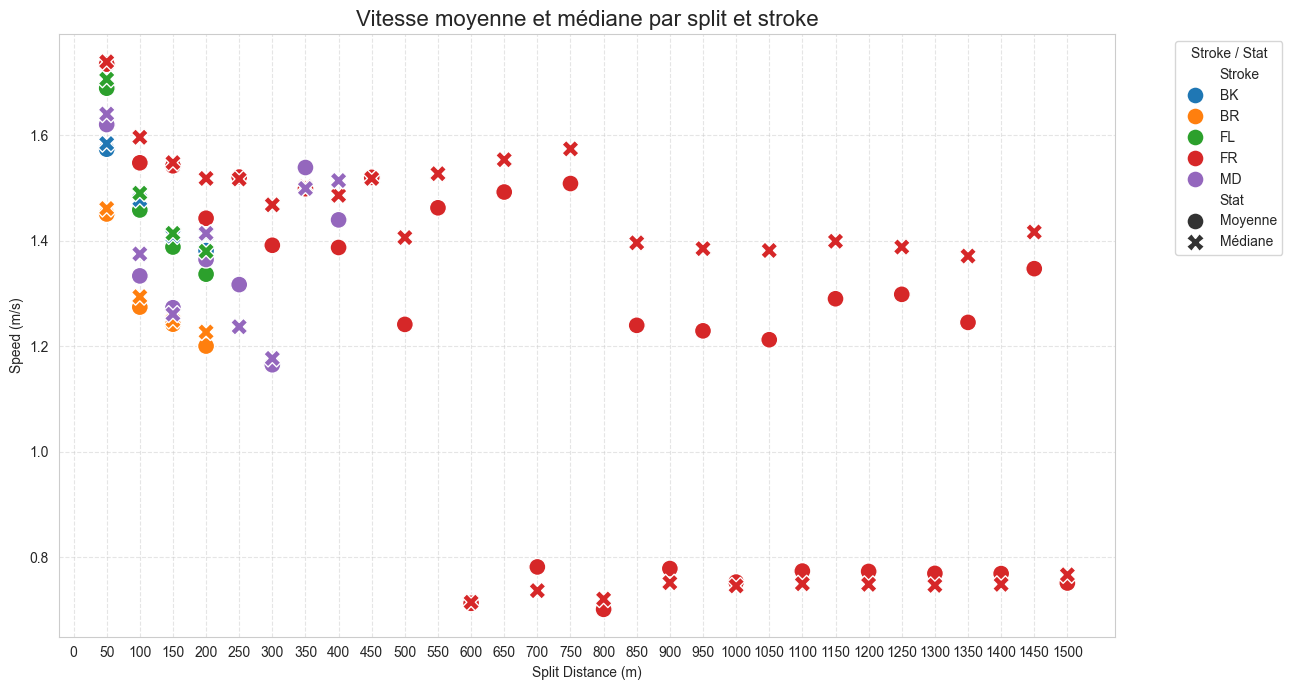

In [82]:
import mplcursors

df_clean = df.loc[df['Speed'].notna(), ['Stroke', 'Distance', 'Speed', 'swimmer', 'splits']].copy()

def clean_swimmer(x):
    if isinstance(x, dict):
        return x.get('Name')
    elif isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict):
        return x[0].get('Name')
    return None

df_clean['Swimmer'] = df_clean['swimmer'].map(clean_swimmer)
df_clean = df_clean.dropna(subset=['Swimmer'])

rows = []
for _, row in df_clean.loc[df_clean['splits'].apply(lambda x: isinstance(x, list) and len(x) > 0)].iterrows():
    stroke = row['Stroke']
    for s in row['splits']:
        split_distance = s.get('split_distance')
        split_speed = s.get('split_speed')
        if split_distance is None or split_speed is None:
            continue
        try:
            dist = int(str(split_distance).replace(' m', '').strip())
            speed = float(split_speed)
            if 0 < speed < 5:
                rows.append({
                    'Stroke': stroke,
                    'SplitDistance': dist,
                    'SplitSpeed': speed
                })
        except Exception:
            continue

df_splits = pd.DataFrame(rows)

df_stats = (
    df_splits
    .groupby(['Stroke', 'SplitDistance'], as_index=False)
    .agg(
        MeanSpeed=('SplitSpeed', 'mean'),
        MedianSpeed=('SplitSpeed', 'median'),
        N=('SplitSpeed', 'size')
    )
)

df_plot = df_stats.melt(
    id_vars=['Stroke', 'SplitDistance', 'N'],
    value_vars=['MeanSpeed', 'MedianSpeed'],
    var_name='Stat',
    value_name='SpeedValue'
)

df_plot['Stat'] = df_plot['Stat'].map({
    'MeanSpeed': 'Moyenne',
    'MedianSpeed': 'Médiane'
})

plt.figure(figsize=(13, 7))
sns.set_style("whitegrid")

ax = sns.scatterplot(
    data=df_plot,
    x='SplitDistance',
    y='SpeedValue',
    hue='Stroke',
    style='Stat',
    s=150
)

if not df_plot.empty:
    max_split = int(df_plot['SplitDistance'].max())
    plt.xticks(np.arange(0, max_split + 50, 50))

points = df_plot[['SplitDistance', 'SpeedValue', 'Stroke', 'Stat', 'N']].to_numpy()
cursor = mplcursors.cursor(ax.collections, hover=True)

@cursor.connect("add")
def on_add(sel):
    x, y = sel.target
    d = (points[:, 0].astype(float) - x) ** 2 + (points[:, 1].astype(float) - y) ** 2
    idx = d.argmin()
    sel.annotation.set_text(
        f"Stroke: {points[idx][2]}\n"
        f"Stat: {points[idx][3]}\n"
        f"Distance: {int(points[idx][0])} m\n"
        f"Speed: {float(points[idx][1]):.3f} m/s\n"
        f"N: {int(points[idx][4])}"
    )

plt.title("Vitesse moyenne et médiane par split et stroke", fontsize=16)
plt.xlabel("Split Distance (m)")
plt.ylabel("Speed (m/s)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Stroke / Stat", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Pacing comparatif</h1>

In [51]:
import re

nom_event = "500 FR LCM"

def parse_event_distance(event_name):
    m = re.search(r"(\d+)", str(event_name))
    return int(m.group(1)) if m else None

def parse_split_distance(x):
    try:
        # gère "500 m", "500m", "500.0 m", etc.
        return int(float(str(x).lower().replace("m", "").strip()))
    except Exception:
        return None

def get_last_split_distance(splits):
    if not isinstance(splits, list) or len(splits) == 0:
        return None
    # on remonte la liste pour trouver le dernier split_distance exploitable
    for s in reversed(splits):
        if not isinstance(s, dict):
            continue
        d = parse_split_distance(s.get("split_distance"))
        if d is not None:
            return d
    return None

def has_valid_splits(splits):
    if not isinstance(splits, list) or len(splits) == 0:
        return False
    for s in splits:
        if isinstance(s, dict) and s.get("split_seconds") is not None:
            return True
    return False

event_distance = parse_event_distance(nom_event)

df_splits_event = df[
    (df["Event"].astype(str).str.strip() == nom_event)
    & (df["splits"].apply(has_valid_splits))
    & (df["splits"].apply(lambda s: get_last_split_distance(s) == event_distance))
].copy()

print("Distance extraite de nom_event :", event_distance)
print("Nombre de performances avec splits valides et dernier split_distance == distance event :", len(df_splits_event))

Distance extraite de nom_event : 500
Nombre de performances avec splits valides et dernier split_distance == distance event : 62


<h2 style="color:gray; font-size:20px;">Split Speed Analysis by Gender with Target Swimmers Comparison</h2>

Distance de l'event : 400
Filtre dernier split appliqué : True
Nombre de performances retenues : 24065


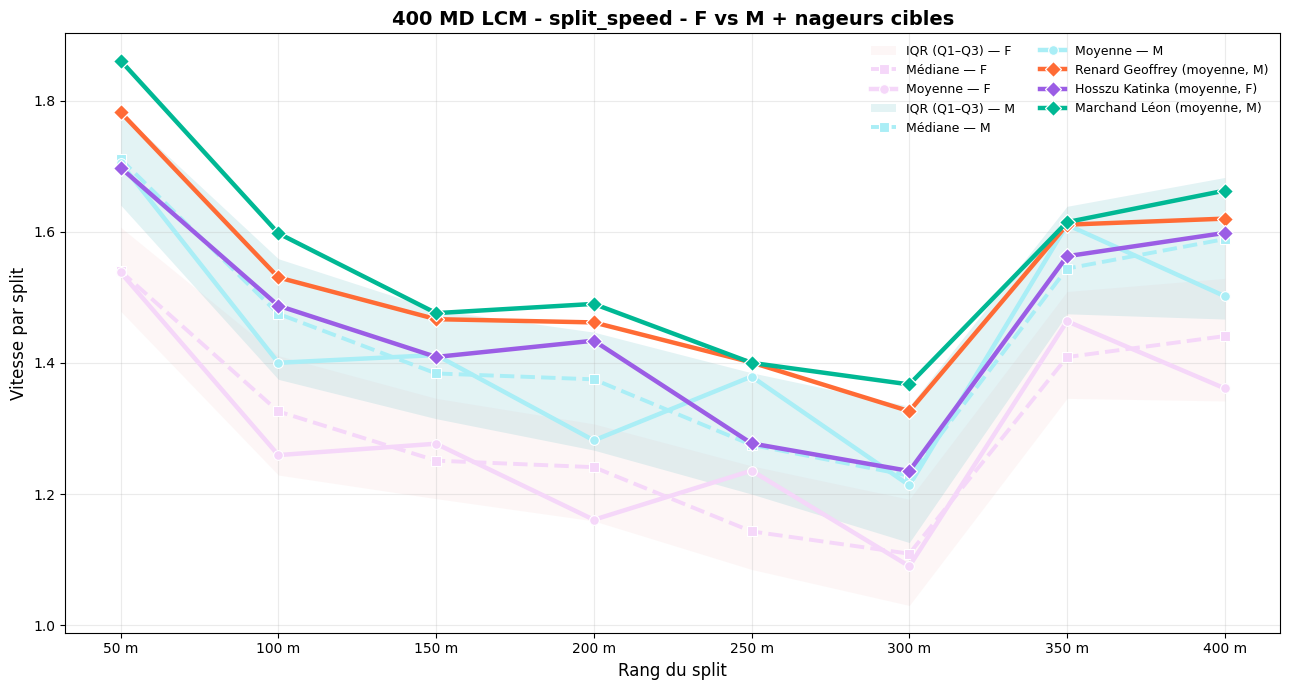

,Gender,split_no,split_distance_theorique,mean,median,q1,q3,n
0,F,1,50,1.5382,1.540,1.479,1.607,9722
1,F,2,100,1.2594,1.326,1.229,1.411,11317
2,F,3,150,1.2768,1.251,1.193,1.346,9503
3,F,4,200,1.1607,1.241,1.159,1.307,11314
4,F,5,250,1.2358,1.143,1.085,1.243,9523
5,F,6,300,1.0898,1.109,1.030,1.192,11313
6,F,7,350,1.4637,1.409,1.346,1.509,9504
7,F,8,400,1.3612,1.441,1.342,1.529,11320
8,M,1,50,1.7052,1.711,1.641,1.783,11032
9,M,2,100,1.4003,1.475,1.375,1.559,12740


,Name,Gender,split_no,split_distance_theorique,target_mean,target_n
0,Hosszu Katinka,F,1,50,1.6979,57
1,Hosszu Katinka,F,2,100,1.4874,58
2,Hosszu Katinka,F,3,150,1.4092,58
3,Hosszu Katinka,F,4,200,1.4340,58
4,Hosszu Katinka,F,5,250,1.2773,57
5,Hosszu Katinka,F,6,300,1.2351,58
6,Hosszu Katinka,F,7,350,1.5629,58
7,Hosszu Katinka,F,8,400,1.5984,58
8,Marchand Léon,M,1,50,1.8613,36
9,Marchand Léon,M,2,100,1.5978,37


Nombre total de valeurs split_speed : 177712


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

nom_event = "400 MD LCM"

swimmer_targets = ["Renard Geoffrey", "Hosszu Katinka", "Marchand Léon"]

target_colors = {
    "Renard Geoffrey": "#FF6B35",
    "Hosszu Katinka": "#9B5DE5",
    "Marchand Léon": "#00B894",
}

style_by_gender = {
    "F": {"fill": "#F9D9D7", "median": "#F5D7F9", "mean": "#F5D7F9"},
    "M": {"fill": "#82C9D1", "median": "#AAEEF6", "mean": "#AAEEF6"},
}

FILL_ALPHA = 0.22
LINE_WIDTH_MED = 2.8
LINE_WIDTH_MEAN = 3.2
MARKER_SIZE = 7


def parse_dist(x):
    try:
        return int(float(str(x).lower().replace("m", "").strip()))
    except Exception:
        return None


def parse_event_distance(event_name):
    try:
        return int(str(event_name).strip().split()[0])
    except Exception:
        return None


def get_last_split_distance(splits):
    if not isinstance(splits, list) or len(splits) == 0:
        return None
    for s in reversed(splits):
        if not isinstance(s, dict):
            continue
        d = parse_dist(s.get("split_distance"))
        if d is not None:
            return d
    return None


def normalize_name(x):
    return str(x).strip().lower() if pd.notna(x) else ""


def to_float(x):
    try:
        return float(x)
    except Exception:
        return None


def has_valid_split_speed(splits):
    if not isinstance(splits, list) or len(splits) == 0:
        return False
    for s in splits:
        if not isinstance(s, dict):
            continue
        d = parse_dist(s.get("split_distance"))
        v = to_float(s.get("split_speed"))
        if d is not None and v is not None:
            return True
    return False


target_set_norm = {normalize_name(n) for n in swimmer_targets}
event_distance = parse_event_distance(nom_event)

# 1) Filtre event + split valide
df_event = df[
    (df["Event"].astype(str).str.strip() == nom_event)
    & df["splits"].apply(has_valid_split_speed)
].copy()

# 2) Filtre "dernier split == distance event" avec fallback
#    Si trop strict => on garde le set sans ce filtre pour éviter df_splits vide
if event_distance is not None:
    df_event_last = df_event[df_event["splits"].apply(lambda s: get_last_split_distance(s) == event_distance)].copy()
    if len(df_event_last) > 0:
        df_event = df_event_last
        applied_last_filter = True
    else:
        applied_last_filter = False
else:
    applied_last_filter = False

print("Distance de l'event :", event_distance)
print("Filtre dernier split appliqué :", applied_last_filter)
print("Nombre de performances retenues :", len(df_event))

split_rows = []
target_rows = []

for _, row in df_event.iterrows():
    swimmers = row.get("swimmer", [])
    splits = row.get("splits", [])

    # Tolérant: accepte len(swimmers) >= 1 (pas uniquement == 1)
    swimmer0 = None
    if isinstance(swimmers, list) and len(swimmers) > 0 and isinstance(swimmers[0], dict):
        swimmer0 = swimmers[0]
    else:
        swimmer0 = {}

    gender = swimmer0.get("Gender")
    name = swimmer0.get("Name")
    if gender not in ["F", "M"]:
        # on ignore pour courbes F/M
        continue

    is_target = normalize_name(name) in target_set_norm

    # Prend tous les splits valides
    for s in splits if isinstance(splits, list) else []:
        if not isinstance(s, dict):
            continue

        dist = parse_dist(s.get("split_distance"))
        speed = to_float(s.get("split_speed"))

        if dist is None or speed is None:
            continue

        split_no = max(1, int(round(dist / 50)))

        split_rows.append(
            {
                "Gender": gender,
                "split_no": split_no,
                "split_distance": dist,
                "split_speed": speed,
            }
        )

        if is_target:
            target_rows.append(
                {
                    "Name": name,
                    "Gender": gender,
                    "split_no": split_no,
                    "split_distance": dist,
                    "split_speed": speed,
                }
            )

df_splits = pd.DataFrame(split_rows)
df_target = pd.DataFrame(target_rows)

# Sécurité: si vide, diagnostic utile
if df_splits.empty:
    print("Aucune donnée exploitable après nettoyage des splits.")
    print("Diagnostic rapide :")
    print("- lignes df_event :", len(df_event))
    print(
        "- swimmers[0] dict :",
        df_event["swimmer"].apply(lambda x: isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict)).sum()
        if "swimmer" in df_event.columns else 0
    )
else:
    stats = (
        df_splits.groupby(["Gender", "split_no"])["split_speed"]
        .agg(
            mean="mean",
            median="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            n="count",
        )
        .reset_index()
        .sort_values(["Gender", "split_no"])
    )

    stats["split_distance_theorique"] = stats["split_no"] * 50

    if not df_target.empty:
        target_stats = (
            df_target.groupby(["Name", "Gender", "split_no"])["split_speed"]
            .agg(target_mean="mean", target_n="count")
            .reset_index()
            .sort_values(["Name", "split_no"])
        )
    else:
        target_stats = pd.DataFrame()

    plt.figure(figsize=(13, 7))

    # Courbes globales F / M
    for g in ["F", "M"]:
        d = stats[stats["Gender"] == g].sort_values("split_no")
        if d.empty:
            continue

        stg = style_by_gender[g]

        plt.fill_between(
            d["split_no"], d["q1"], d["q3"],
            color=stg["fill"], alpha=FILL_ALPHA, linewidth=0,
            label=f"IQR (Q1–Q3) — {g}",
        )

        plt.plot(
            d["split_no"], d["median"],
            color=stg["median"], linewidth=LINE_WIDTH_MED, linestyle="--",
            marker="s", markersize=MARKER_SIZE, markeredgecolor="white", markeredgewidth=0.8,
            label=f"Médiane — {g}", zorder=5,
        )

        plt.plot(
            d["split_no"], d["mean"],
            color=stg["mean"], linewidth=LINE_WIDTH_MEAN, linestyle="-",
            marker="o", markersize=MARKER_SIZE, markeredgecolor="white", markeredgewidth=0.8,
            label=f"Moyenne — {g}", zorder=6,
        )

    # Courbes nageurs cibles
    if not target_stats.empty:
        for swimmer in swimmer_targets:
            d_sw = target_stats[
                target_stats["Name"].apply(normalize_name) == normalize_name(swimmer)
            ].sort_values("split_no")
            if d_sw.empty:
                continue

            tg = d_sw.iloc[0]["Gender"]
            color_sw = target_colors.get(swimmer, "#222222")

            plt.plot(
                d_sw["split_no"], d_sw["target_mean"],
                color=color_sw, linewidth=3.2, linestyle="-",
                marker="D", markersize=8, markeredgecolor="white", markeredgewidth=0.9,
                label=f"{swimmer} (moyenne, {tg})", zorder=7,
            )

    # Axe x dynamique
    ticks = sorted(df_splits["split_no"].dropna().astype(int).unique().tolist())
    labels = [f"{t * 50} m" for t in ticks]
    plt.xticks(ticks, labels)

    plt.title(f"{nom_event} - split_speed - F vs M + nageurs cibles", fontsize=14, weight="bold")
    plt.xlabel("Rang du split", fontsize=12)
    plt.ylabel("Vitesse par split", fontsize=12)
    plt.grid(alpha=0.25)
    plt.legend(ncol=2, frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

    stats_display = stats.copy()
    for col in ["mean", "median", "q1", "q3"]:
        stats_display[col] = stats_display[col].round(4)

    display(
        stats_display[
            ["Gender", "split_no", "split_distance_theorique", "mean", "median", "q1", "q3", "n"]
        ]
    )

    if not target_stats.empty:
        target_display = target_stats.copy()
        target_display["split_distance_theorique"] = target_display["split_no"] * 50
        target_display["target_mean"] = target_display["target_mean"].round(4)

        display(
            target_display[
                ["Name", "Gender", "split_no", "split_distance_theorique", "target_mean", "target_n"]
            ].sort_values(["Name", "split_no"])
        )

    print("Nombre total de valeurs split_speed :", len(df_splits))

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Petites vérifications</p>

<h2 style="color:gray; font-size:20px;">Vitesse max pour un split avec le meet correspondant</h2>

In [13]:
df_md = df[df["Stroke"].astype("string").str.strip().eq("FR")].copy()

df_md = df_md.explode("splits")
df_md = df_md[df_md["splits"].apply(lambda x: isinstance(x, dict))].copy()

df_md["split_distance"] = df_md["splits"].apply(lambda x: str(x.get("split_distance", "")).strip())
df_md["split_speed"] = pd.to_numeric(
    df_md["splits"].apply(lambda x: x.get("split_speed")),
    errors="coerce"
)

df_150 = df_md[df_md["split_distance"].eq("1400 m") & df_md["split_speed"].notna()].copy()

if df_150.empty:
    print("Aucune valeur de split_speed trouvée pour Stroke='MD' au split_distance='1400 m'.")
else:
    idx = df_150["split_speed"].idxmax()
    row_max = df_150.loc[idx]

    print(f"split_speed max (MD, 150 m) : {row_max['split_speed']}")
    print(f"Meet correspondant           : {row_max['Meet']}")

split_speed max (MD, 150 m) : 1.606
Meet correspondant           : Championnats d'Europe Juniors


<h1 style="color:rgb(242, 176, 235); font-size:32px;">Évolution de la vitesse par splits</h1>

<h2 style="color:gray; font-size:20px;">Lineplot of Speed ​​per split for a precise Swimmer and Event</h2>

/var/folders/cj/0py9gq5134z1x15x944dgq5m0000gn/T/ipykernel_9079/3746562417.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


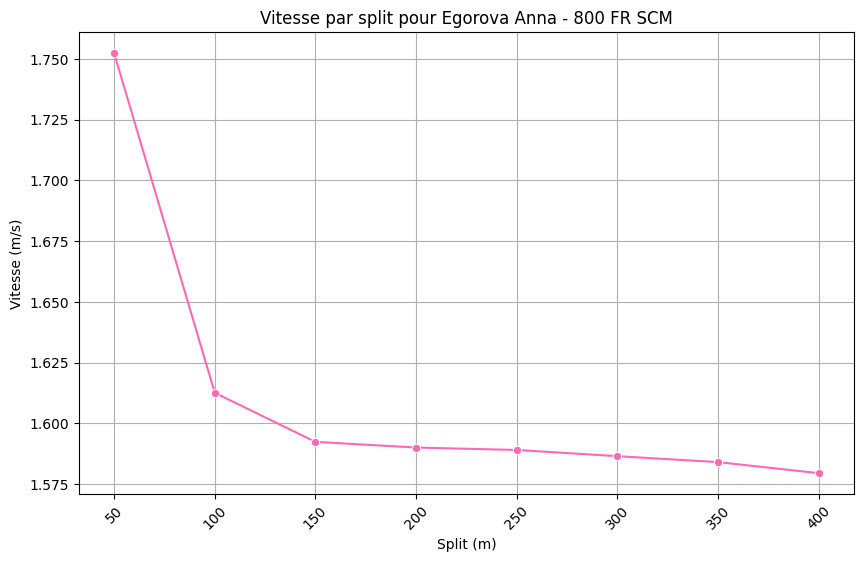

In [14]:
nom_nageur = "Egorova Anna"
nom_event = "800 FR SCM"

split_data = []
gender_nageur = None  

for idx, row in df.iterrows():
    if row['Event'] == nom_event and len(row['swimmer']) == 1:
        swimmer = row['swimmer'][0]
        if swimmer['Name'] == nom_nageur:
            gender_nageur = swimmer.get('Gender')  
            for s in row['splits']:
                if s['split_speed'] is not None:
                    dist = int(s['split_distance'].replace(' m',''))
                    split_data.append({
                        'split_distance': dist,
                        'split_speed': s['split_speed']
                    })

df_splits = pd.DataFrame(split_data)

df_splits = df_splits.sort_values('split_distance')

if gender_nageur == "M":
    color_line = "#003E80"  
elif gender_nageur == "F":
    color_line = "#FF69B4"  
else:
    color_line = "#008080"  

plt.figure(figsize=(10,6))
sns.lineplot(
    x='split_distance',
    y='split_speed',
    data=df_splits,
    marker='o',
    color=color_line,
    ci=None  
)
plt.xticks(range(50, df_splits['split_distance'].max()+50, 50), rotation=45) 
plt.title(f"Vitesse par split pour {nom_nageur} - {nom_event}")
plt.xlabel("Split (m)")
plt.ylabel("Vitesse (m/s)")
plt.grid(True)
plt.show()

<h2 style="color:gray; font-size:20px;">Lineplot of split speed for the best swimmers for a specific event (women vs men)</h2>

In [15]:
import pandas as pd

nom_event = "400 MD LCM"
annee_debut = 2022
annee_fin = 2026

df_work = df.copy()

# Nettoyage des noms de colonnes (espaces)
df_work.columns = df_work.columns.map(lambda x: str(x).strip())

# --- Trouver les colonnes indispensables (robuste) ---
event_col = next((c for c in df_work.columns if c.lower() == "event"), None)
swimtime_col = next((c for c in df_work.columns if c.lower() == "swimtimeseconds"), None)
swimmer_col = next((c for c in df_work.columns if c.lower() == "swimmer"), None)

if event_col is None:
    raise ValueError(f"Colonne 'Event' introuvable. Colonnes dispo: {df_work.columns.tolist()}")
if swimtime_col is None:
    raise ValueError(f"Colonne 'SwimTimeSeconds' introuvable. Colonnes dispo: {df_work.columns.tolist()}")
if swimmer_col is None:
    raise ValueError(f"Colonne 'swimmer' introuvable. Colonnes dispo: {df_work.columns.tolist()}")

# --- 1) Créer la colonne 'year' à partir de la meilleure colonne possible ---
# Priorité: une colonne contenant "year" dans son nom (ex: SwimYear)
year_candidates = [c for c in df_work.columns if "year" in c.lower()]
# fallback: sinon une colonne contenant "date" dans son nom (ex: SwimDate, mpp_date)
date_candidates = [c for c in df_work.columns if "date" in c.lower()]

chosen_year_col = None
for pref in ["swimyear", "year", "meetyear", "competitionyear"]:
    cand = next((c for c in year_candidates if c.lower() == pref), None)
    if cand is not None:
        chosen_year_col = cand
        break
if chosen_year_col is None and len(year_candidates) > 0:
    chosen_year_col = year_candidates[0]

if chosen_year_col is not None:
    df_work["year"] = pd.to_numeric(df_work[chosen_year_col], errors="coerce")
else:
    chosen_date_col = None
    for pref in ["swimdate", "date", "mpp_date", "meetdate", "competitiondate"]:
        cand = next((c for c in date_candidates if c.lower() == pref), None)
        if cand is not None:
            chosen_date_col = cand
            break
    if chosen_date_col is None and len(date_candidates) > 0:
        chosen_date_col = date_candidates[0]

    if chosen_date_col is None:
        raise ValueError(
            "Aucune colonne pour l'annee trouvée (Year/Date/variantes). "
            f"Colonnes dispo: {df_work.columns.tolist()}"
        )

    df_work["year"] = pd.to_datetime(df_work[chosen_date_col], errors="coerce").dt.year

# --- 2) Filtrer l'événement ---
df_event = df_work[
    (df_work[event_col] == nom_event) &
    (df_work[swimtime_col].notna()) &
    (df_work[swimmer_col].apply(lambda x: isinstance(x, list) and len(x) == 1)) &
    (df_work["year"].between(annee_debut, annee_fin))
].copy()

if df_event.empty:
    print(f"Aucune performance pour {nom_event} entre {annee_debut} et {annee_fin}.")
else:
    # Extraire infos swimmer depuis la structure swimmer=[{...}]
    def get_field(sw, field):
        if isinstance(sw, list) and len(sw) == 1 and isinstance(sw[0], dict):
            return sw[0].get(field)
        return None

    df_event["swimmer_name"] = df_event[swimmer_col].apply(lambda x: get_field(x, "Name"))
    df_event["swimmer_gender"] = df_event[swimmer_col].apply(lambda x: get_field(x, "Gender"))

    best_row = df_event.nsmallest(1, swimtime_col).iloc[0]

    best_name = best_row["swimmer_name"]
    best_gender = best_row["swimmer_gender"]
    best_time = best_row[swimtime_col]
    best_year = best_row["year"]

    # meet si dispo
    meet_col = next((c for c in df_event.columns if c.lower() == "meet"), None)
    best_meet = best_row[meet_col] if meet_col is not None else "Meet non disponible"

    print(f"Best swimmer ({annee_debut}-{annee_fin}) - {nom_event}")
    print(f"Nageur : {best_name} ({best_gender})")
    print(f"Temps  : {best_time:.2f} sec")
    print(f"Annee  : {int(best_year) if pd.notna(best_year) else 'N/A'}")
    print(f"Meet   : {best_meet}")

Best swimmer (2022-2026) - 400 MD LCM
Nageur : Marchand Léon (M)
Temps  : 242.50 sec
Annee  : 2023
Meet   : Championnats du Monde en grand bassin


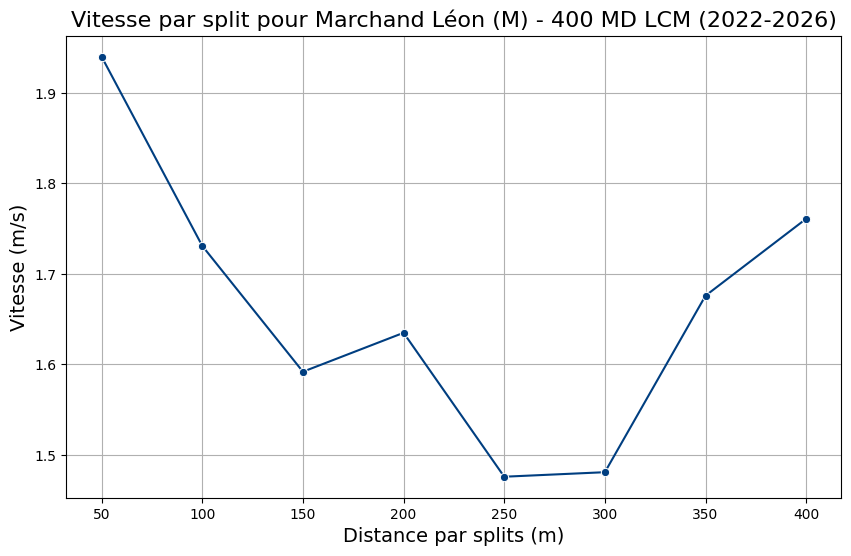

In [17]:
nom_event = "400 MD LCM"
annee_debut = 2022
annee_fin = 2026

df_work = df.copy()

# Nettoyage (au cas où il y a des espaces)
df_work.columns = df_work.columns.map(lambda x: str(x).strip())

# --- FIX: détecter la bonne colonne année ---
year_col = None

# Priorité: SwimYear (dans ton dataset)
if "SwimYear" in df_work.columns:
    year_col = "SwimYear"
elif "Year" in df_work.columns:
    year_col = "Year"
else:
    # fallback: toute colonne contenant "year"
    year_candidates = [c for c in df_work.columns if "year" in c.lower()]
    if year_candidates:
        year_col = year_candidates[0]

if year_col is not None:
    df_work["year"] = pd.to_numeric(df_work[year_col], errors="coerce")
else:
    # Si pas d'année: essayer via Date
    date_col = None
    if "SwimDate" in df_work.columns:
        date_col = "SwimDate"
    elif "Date" in df_work.columns:
        date_col = "Date"
    elif "mpp_date" in df_work.columns:
        date_col = "mpp_date"
    else:
        date_candidates = [c for c in df_work.columns if "date" in c.lower()]
        if date_candidates:
            date_col = date_candidates[0]

    if date_col is None:
        raise ValueError(
            "Aucune colonne pour l'annee trouvée (SwimYear/Year/Date/variantes). "
            f"Colonnes dispo: {df_work.columns.tolist()}"
        )

    df_work["year"] = pd.to_datetime(df_work[date_col], errors="coerce").dt.year
# --- FIN FIX ---

df_event = df_work[
    (df_work["Event"] == nom_event) &
    (df_work["SwimTimeSeconds"].notna()) &
    (df_work["swimmer"].apply(lambda x: isinstance(x, list) and len(x) == 1)) &
    (df_work["year"].between(annee_debut, annee_fin))
].copy()

if df_event.empty:
    print(f"Aucune performance pour {nom_event} entre {annee_debut} et {annee_fin}.")
else:
    df_event["swimmer_name"] = df_event["swimmer"].apply(lambda x: x[0]["Name"])
    df_event["swimmer_gender"] = df_event["swimmer"].apply(lambda x: x[0]["Gender"])

    df_best = df_event.nsmallest(1, "SwimTimeSeconds").iloc[0]

    best_name = df_best["swimmer_name"]
    best_gender = df_best["swimmer_gender"]
    best_splits = df_best["splits"]

    split_data = []
    if isinstance(best_splits, list):
        for s in best_splits:
            if isinstance(s, dict) and s.get("split_speed") is not None and s.get("split_distance") is not None:
                try:
                    dist = int(str(s["split_distance"]).replace(" m", "").strip())
                    split_data.append({
                        "split_distance": dist,
                        "split_speed": float(s["split_speed"])
                    })
                except Exception:
                    continue

    df_splits = pd.DataFrame(split_data)

    if df_splits.empty:
        print(f"Aucun split valide trouve pour le meilleur nageur de l'Event {nom_event} ({annee_debut}-{annee_fin}).")
    else:
        plt.figure(figsize=(10, 6))
        color = "#003E80" if best_gender == "M" else "#FF69B4"

        sns.lineplot(
            x="split_distance",
            y="split_speed",
            data=df_splits,
            marker="o",
            color=color
        )

        plt.xticks(range(50, df_splits["split_distance"].max() + 50, 50))
        plt.title(
            f"Vitesse par split pour {best_name} ({best_gender}) - {nom_event} ({annee_debut}-{annee_fin})",
            fontsize=16
        )
        plt.xlabel("Distance par splits (m)", fontsize=14)
        plt.ylabel("Vitesse (m/s)", fontsize=14)
        plt.grid(True)
        plt.show()

<h2 style="color:gray; font-size:20px;">Lineplot of Split Speed Progression of the Best Swimmer in a Given Event (Women vs Men)</h2>

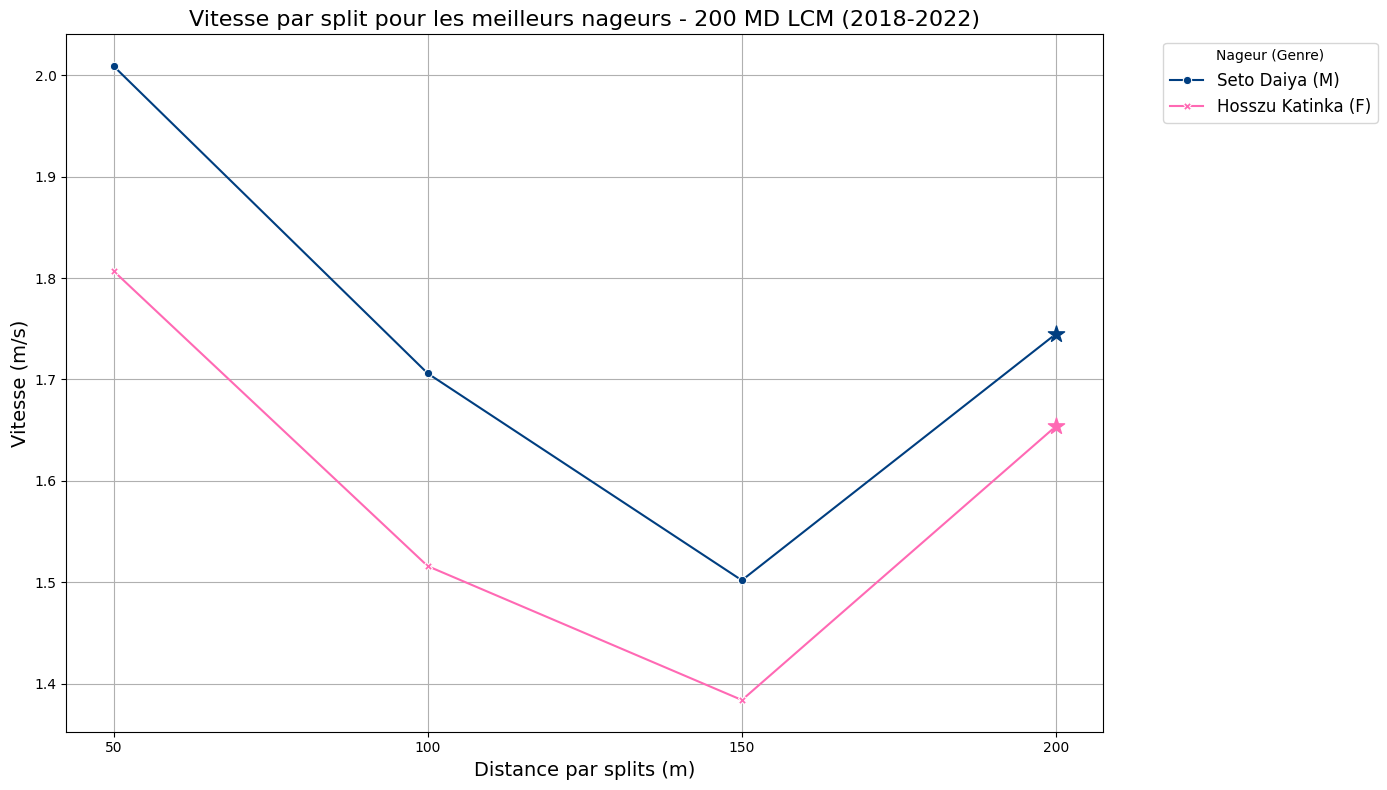

In [20]:
nom_event = "200 MD LCM"
top_n = 1
annee_debut = 2018
annee_fin = 2022

df_work = df.copy()

# Nettoyage des noms de colonnes
df_work.columns = df_work.columns.map(lambda x: str(x).strip())

# Détection robuste de la colonne année/date
if 'SwimYear' in df_work.columns:
    df_work['year'] = pd.to_numeric(df_work['SwimYear'], errors='coerce')
elif 'Year' in df_work.columns:
    df_work['year'] = pd.to_numeric(df_work['Year'], errors='coerce')
elif 'SwimDate' in df_work.columns:
    df_work['year'] = pd.to_datetime(df_work['SwimDate'], errors='coerce').dt.year
elif 'Date' in df_work.columns:
    df_work['year'] = pd.to_datetime(df_work['Date'], errors='coerce').dt.year
elif 'mpp_date' in df_work.columns:
    df_work['year'] = pd.to_datetime(df_work['mpp_date'], errors='coerce').dt.year
else:
    raise ValueError(
        "Aucune colonne annee/date trouvee. Colonnes dispo: "
        f"{df_work.columns.tolist()}"
    )

df_event = df_work[
    (df_work['Event'] == nom_event) &
    (df_work['SwimTimeSeconds'].notna()) &
    (df_work['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1)) &
    (df_work['year'].between(annee_debut, annee_fin))
].copy()

if df_event.empty:
    print(f"Aucune performance pour {nom_event} entre {annee_debut} et {annee_fin}.")
else:
    df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0]['Name'])
    df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0]['Gender'])

    df_top_men = df_event[df_event['swimmer_gender'] == 'M'].nsmallest(top_n, 'SwimTimeSeconds')
    df_top_women = df_event[df_event['swimmer_gender'] == 'F'].nsmallest(top_n, 'SwimTimeSeconds')
    df_top_all = pd.concat([df_top_men, df_top_women], ignore_index=True)

    split_data = []
    for _, row in df_top_all.iterrows():
        swimmer_name = row['swimmer_name']
        gender = row['swimmer_gender']
        splits = row['splits']

        if isinstance(splits, list) and len(splits) > 0:
            for s in splits:
                if isinstance(s, dict) and s.get('split_speed') is not None and s.get('split_distance') is not None:
                    try:
                        dist = int(str(s['split_distance']).replace(' m', '').strip())
                        split_data.append({
                            'swimmer': swimmer_name,
                            'gender': gender,
                            'split_distance': dist,
                            'split_speed': float(s['split_speed'])
                        })
                    except Exception:
                        continue

    df_splits = pd.DataFrame(split_data)

    if df_splits.empty:
        print("Aucun split valide trouve pour les top nageurs.")
    else:
        df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'] + ")"

        palette_colors = {'M': "#003E80", 'F': "#FF69B4"}
        labels_gender = df_splits[['swimmer_label', 'gender']].drop_duplicates()
        palette_for_plot = {
            r['swimmer_label']: palette_colors.get(r['gender'], "#777777")
            for _, r in labels_gender.iterrows()
        }

        plt.figure(figsize=(14, 8))
        sns.lineplot(
            x='split_distance',
            y='split_speed',
            hue='swimmer_label',
            style='swimmer_label',
            data=df_splits,
            markers=True,
            dashes=False,
            palette=palette_for_plot
        )

        plt.xticks(range(50, df_splits['split_distance'].max() + 50, 50))
        plt.title(
            f"Vitesse par split pour les meilleurs nageurs - {nom_event} ({annee_debut}-{annee_fin})",
            fontsize=16
        )
        plt.xlabel("Distance par splits (m)", fontsize=14)
        plt.ylabel("Vitesse (m/s)", fontsize=14)
        plt.grid(True)
        plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

        if not df_top_men.empty:
            best_male = df_top_men.nsmallest(1, 'SwimTimeSeconds')['swimmer_name'].iloc[0]
            swimmer_data = df_splits[df_splits['swimmer'] == best_male]
            if not swimmer_data.empty:
                label = f"{best_male} ({swimmer_data['gender'].iloc[0]})"
                plt.scatter(
                    swimmer_data['split_distance'].iloc[-1],
                    swimmer_data['split_speed'].iloc[-1],
                    s=150,
                    color=palette_for_plot[label],
                    marker='*',
                    zorder=5
                )

        if not df_top_women.empty:
            best_female = df_top_women.nsmallest(1, 'SwimTimeSeconds')['swimmer_name'].iloc[0]
            swimmer_data = df_splits[df_splits['swimmer'] == best_female]
            if not swimmer_data.empty:
                label = f"{best_female} ({swimmer_data['gender'].iloc[0]})"
                plt.scatter(
                    swimmer_data['split_distance'].iloc[-1],
                    swimmer_data['split_speed'].iloc[-1],
                    s=150,
                    color=palette_for_plot[label],
                    marker='*',
                    zorder=5
                )

        plt.tight_layout()
        plt.show()

<h2 style="color:gray; font-size:20px;">Line plot of Split Speed Progression of Top 10 Swimmers in a given Event (Women vs Men)</h2>

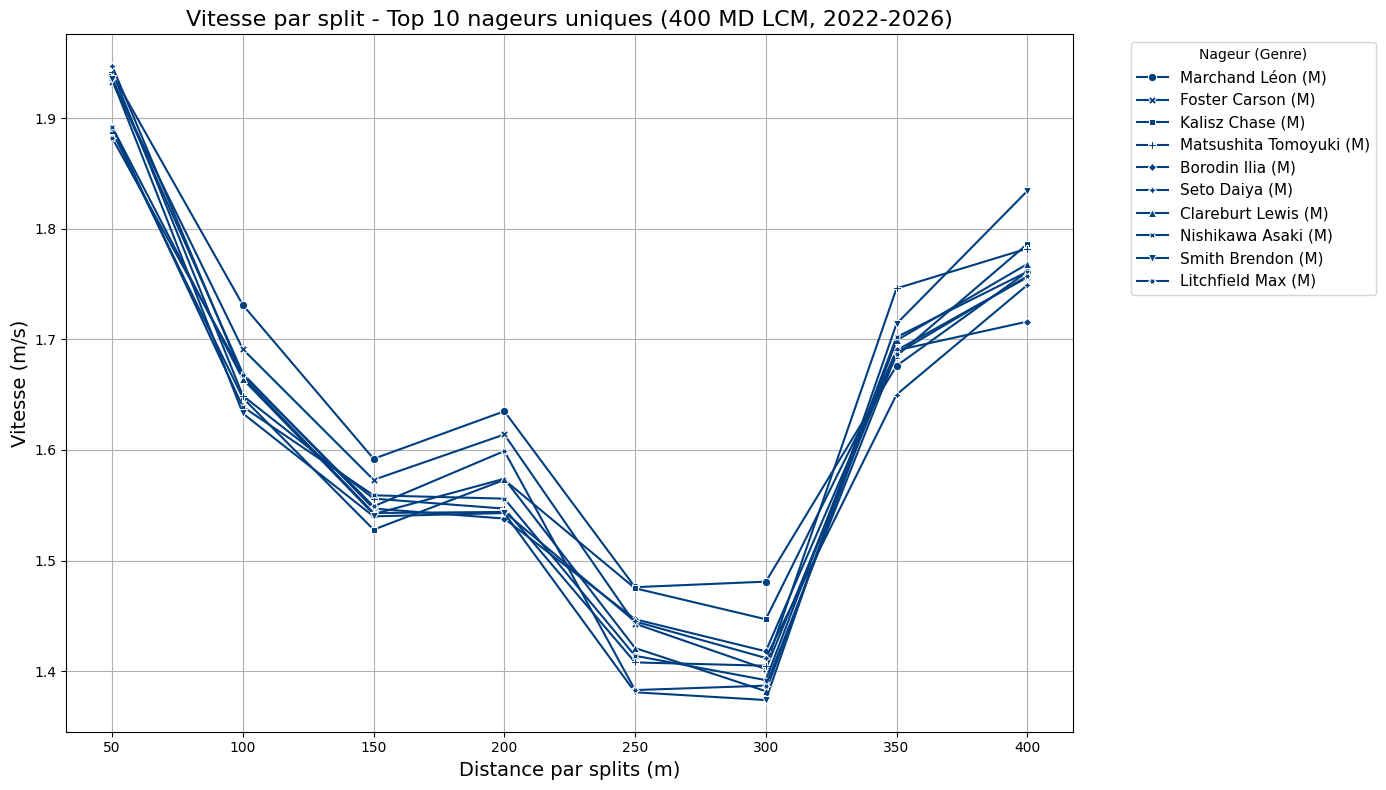

          swimmer_name swimmer_gender  SwimTimeSeconds  year
0        Marchand Léon              M           242.50  2023
1        Foster Carson              M           246.56  2022
2         Kalisz Chase              M           247.47  2022
3  Matsushita Tomoyuki              M           248.32  2025
4         Borodin Ilia              M           249.16  2025
5           Seto Daiya              M           249.41  2023
6      Clareburt Lewis              M           249.72  2024
7      Nishikawa Asaki              M           250.21  2025
8        Smith Brendon              M           250.37  2023
9       Litchfield Max              M           250.40  2024


In [21]:
nom_event = "400 MD LCM"
top_n = 10

annee_debut = 2022
annee_fin = 2026

df_work = df.copy()

# Nettoyage des noms de colonnes
df_work.columns = df_work.columns.map(lambda x: str(x).strip())

# --- FIX: créer 'year' depuis SwimYear/SwimDate (ou variantes) ---
year_col = None
if "SwimYear" in df_work.columns:
    year_col = "SwimYear"
elif "Year" in df_work.columns:
    year_col = "Year"
else:
    # fallback: chercher une colonne qui contient "year"
    year_candidates = [c for c in df_work.columns if "year" in c.lower()]
    if year_candidates:
        year_col = year_candidates[0]

if year_col is not None:
    df_work["year"] = pd.to_numeric(df_work[year_col], errors="coerce")
else:
    # fallback date -> year
    date_col = None
    for c in ["SwimDate", "Date", "mpp_date", "MeetDate", "MeetDate", "CompetitionDate", "competition_date"]:
        if c in df_work.columns:
            date_col = c
            break
    if date_col is None:
        # fallback: toute colonne contenant "date"
        date_candidates = [c for c in df_work.columns if "date" in c.lower()]
        if date_candidates:
            date_col = date_candidates[0]

    if date_col is None:
        raise ValueError(
            "Aucune colonne pour l'annee trouvée (SwimYear/Year/SwimDate/Date/mpp_date/variantes). "
            f"Colonnes dispo: {df_work.columns.tolist()}"
        )

    df_work["year"] = pd.to_datetime(df_work[date_col], errors="coerce").dt.year
# --- fin FIX ---

df_event = df_work[
    (df_work['Event'] == nom_event) &
    (df_work['SwimTimeSeconds'].notna()) &
    (df_work['swimmer'].apply(lambda x: isinstance(x, list) and len(x) == 1)) &
    (df_work['year'].between(annee_debut, annee_fin))
].copy()

if df_event.empty:
    print(f"Aucune performance pour {nom_event} entre {annee_debut} et {annee_fin}.")
else:
    df_event['swimmer_name'] = df_event['swimmer'].apply(lambda x: x[0].get('Name'))
    df_event['swimmer_gender'] = df_event['swimmer'].apply(lambda x: x[0].get('Gender'))

    df_best_per_swimmer = (
        df_event
        .sort_values('SwimTimeSeconds', ascending=True)
        .drop_duplicates(subset=['swimmer_name'], keep='first')
    )

    df_top_all = df_best_per_swimmer.nsmallest(top_n, 'SwimTimeSeconds').copy()

    if df_top_all.empty:
        print(f"Aucun nageur unique trouve pour {nom_event} entre {annee_debut} et {annee_fin}.")
    else:
        split_data = []
        for _, row in df_top_all.iterrows():
            swimmer_name = row['swimmer_name']
            gender = row['swimmer_gender']
            splits = row['splits']

            if isinstance(splits, list) and len(splits) > 0:
                for s in splits:
                    if isinstance(s, dict) and s.get('split_speed') is not None and s.get('split_distance') is not None:
                        try:
                            dist = int(str(s['split_distance']).replace(' m', '').strip())
                            split_data.append({
                                'swimmer': swimmer_name,
                                'gender': gender,
                                'split_distance': dist,
                                'split_speed': float(s['split_speed'])
                            })
                        except Exception:
                            continue

        df_splits = pd.DataFrame(split_data)

        if df_splits.empty:
            print("Aucun split valide trouve pour les top nageurs.")
        else:
            df_splits['swimmer_label'] = df_splits['swimmer'] + " (" + df_splits['gender'].fillna('?') + ")"

            palette_colors = {'M': "#003E80", 'F': "#FF69B4"}
            labels_gender = df_splits[['swimmer_label', 'gender']].drop_duplicates()

            palette_for_plot = {}
            for _, r in labels_gender.iterrows():
                palette_for_plot[r['swimmer_label']] = palette_colors.get(r['gender'], "#777777")

            plt.figure(figsize=(14, 8))
            sns.lineplot(
                x='split_distance',
                y='split_speed',
                hue='swimmer_label',
                style='swimmer_label',
                data=df_splits,
                markers=True,
                dashes=False,
                palette=palette_for_plot
            )

            plt.xticks(range(50, df_splits['split_distance'].max() + 50, 50))
            plt.title(f"Vitesse par split - Top {top_n} nageurs uniques ({nom_event}, {annee_debut}-{annee_fin})", fontsize=16)
            plt.xlabel("Distance par splits (m)", fontsize=14)
            plt.ylabel("Vitesse (m/s)", fontsize=14)
            plt.grid(True)
            plt.legend(title='Nageur (Genre)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
            plt.tight_layout()
            plt.show()

            display_cols = ['swimmer_name', 'swimmer_gender', 'SwimTimeSeconds', 'year']
            print(df_top_all[display_cols].reset_index(drop=True))

<h2 style="color:gray; font-size:20px;">Comparative Heatmap of Swim Speed by Distance and Stroke</h2>

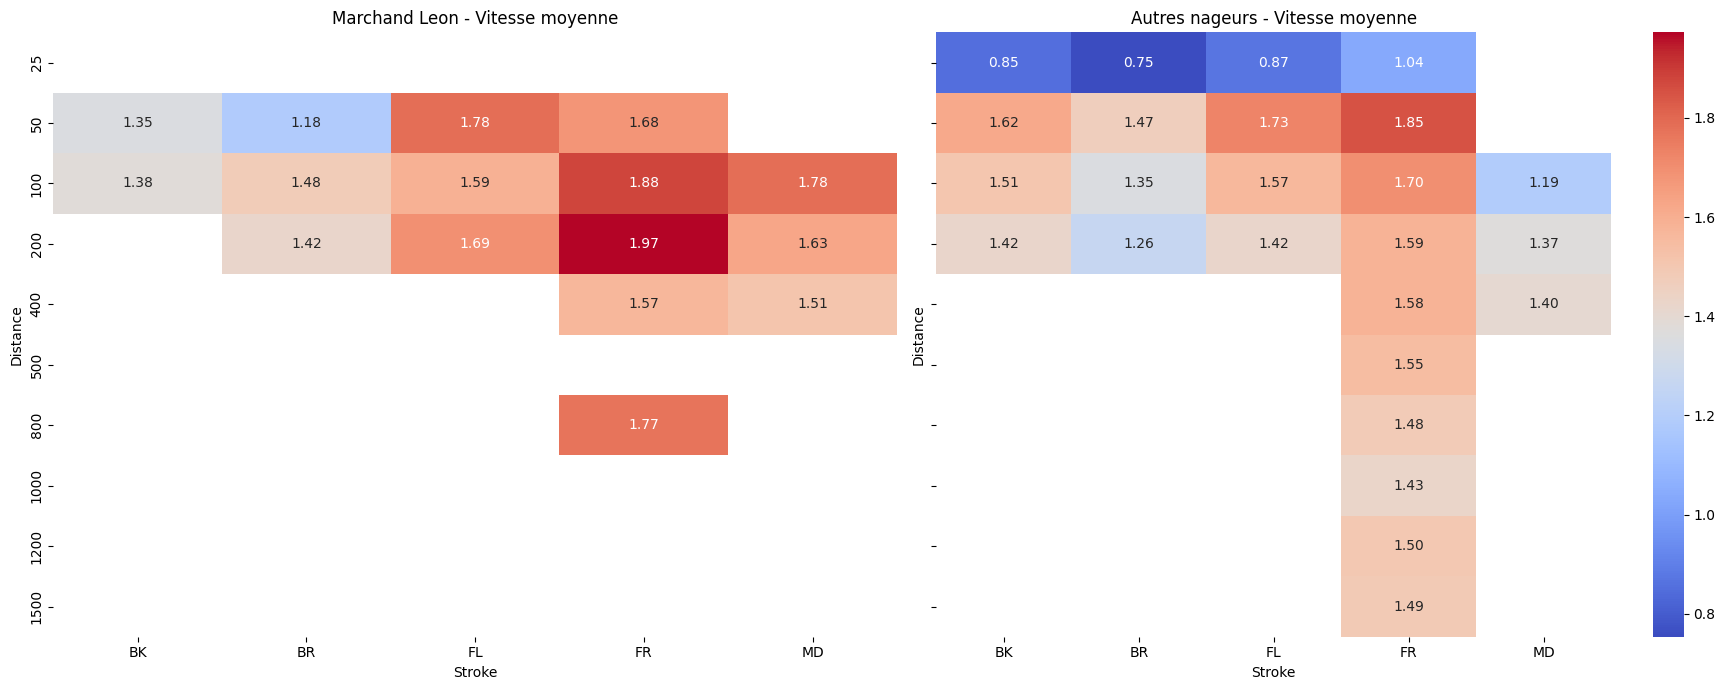

In [22]:
import unicodedata

nageur_cible = "Marchand Leon"

def norm_txt(x):
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFD", x)
    x = "".join(ch for ch in x if unicodedata.category(ch) != "Mn")  # retire accents
    x = " ".join(x.split())
    return x

df_cmp = df.copy()

df_cmp = df_cmp.explode("swimmer")
df_cmp = df_cmp[df_cmp["swimmer"].apply(lambda x: isinstance(x, dict))].copy()

# Colonnes utiles
df_cmp["Nageur"] = df_cmp["swimmer"].apply(lambda x: x.get("Name"))
df_cmp["Speed"] = pd.to_numeric(df_cmp["Speed"], errors="coerce")
df_cmp["Distance"] = pd.to_numeric(df_cmp["Distance"], errors="coerce")
df_cmp["Stroke"] = df_cmp["Stroke"].astype(str).str.strip()

# Normalisation nom nageur
df_cmp["Nageur_norm"] = df_cmp["Nageur"].map(norm_txt)
nageur_norm = norm_txt(nageur_cible)

df_cmp = df_cmp[
    df_cmp["Speed"].notna()
    & df_cmp["Distance"].notna()
    & df_cmp["Stroke"].notna()
    & (df_cmp["Stroke"].str.strip() != "")
].copy()

df_cmp["Groupe"] = df_cmp["Nageur_norm"].apply(
    lambda n: "Nageur cible" if nageur_norm in n else "Autres nageurs"
)

# Vérif présence nageur
nb_target = (df_cmp["Groupe"] == "Nageur cible").sum()
if nb_target == 0:
    print(f"Aucune ligne trouvée pour le nageur '{nageur_cible}'.")
    print("\nExemples de nageurs disponibles :")
    print(df_cmp["Nageur"].dropna().value_counts().head(30))
else:
    # Pivot vitesse moyenne par Distance x Stroke
    pivot_target = df_cmp[df_cmp["Groupe"] == "Nageur cible"].pivot_table(
        values="Speed", index="Distance", columns="Stroke", aggfunc="mean"
    )
    pivot_others = df_cmp[df_cmp["Groupe"] == "Autres nageurs"].pivot_table(
        values="Speed", index="Distance", columns="Stroke", aggfunc="mean"
    )

    all_idx = sorted(set(pivot_target.index).union(set(pivot_others.index)))
    all_cols = sorted(set(pivot_target.columns).union(set(pivot_others.columns)))
    pivot_target = pivot_target.reindex(index=all_idx, columns=all_cols)
    pivot_others = pivot_others.reindex(index=all_idx, columns=all_cols)

    vmin = min(pivot_target.min().min(skipna=True), pivot_others.min().min(skipna=True))
    vmax = max(pivot_target.max().max(skipna=True), pivot_others.max().max(skipna=True))

    def draw_heatmap(ax, piv, title, cbar=False):
        if piv.empty or piv.dropna(how="all").dropna(axis=1, how="all").empty:
            ax.text(0.5, 0.5, "Pas de donnees disponibles", ha="center", va="center", fontsize=12)
            ax.set_title(title)
            ax.set_xlabel("Stroke")
            ax.set_ylabel("Distance")
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            sns.heatmap(
                piv,
                annot=True,
                fmt=".2f",
                cmap="coolwarm",
                ax=ax,
                cbar=cbar,
                vmin=vmin,
                vmax=vmax
            )
            ax.set_title(title)
            ax.set_xlabel("Stroke")
            ax.set_ylabel("Distance")

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
    draw_heatmap(axes[0], pivot_target, f"{nageur_cible} - Vitesse moyenne", cbar=False)
    draw_heatmap(axes[1], pivot_others, "Autres nageurs - Vitesse moyenne", cbar=True)
    plt.tight_layout()
    plt.show()

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Comparaisons de pacing par splits (à partir de la médiane)</h1>

<h2 style="color:gray; font-size:20px;">Lineplot of median swim time by splits</h2>

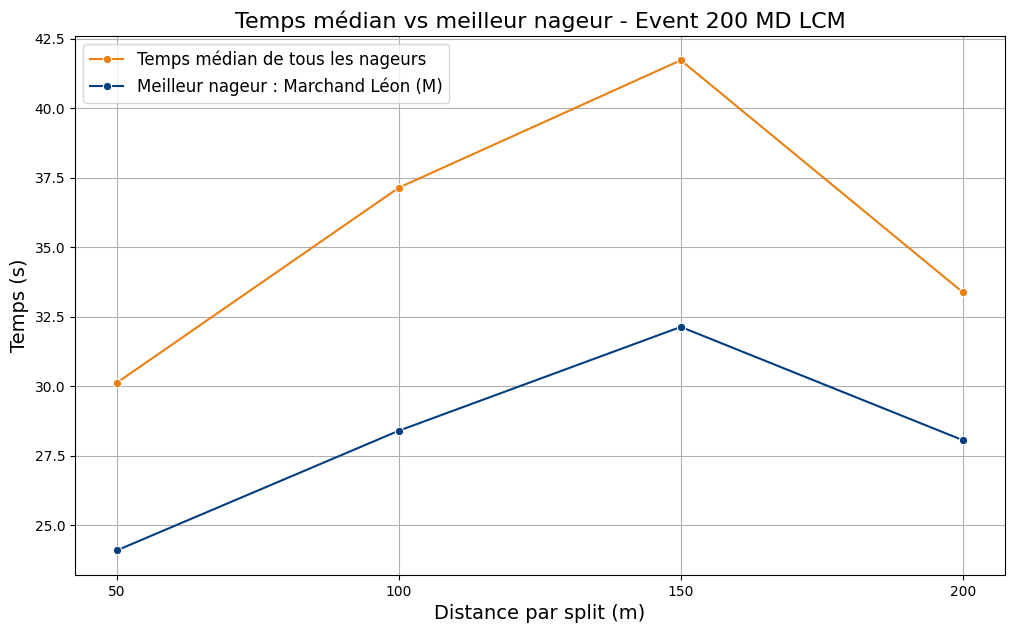

In [49]:
nom_event = "200 MD LCM"  

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_median_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].median()

# Meilleur nageur
df_best = df_event.nsmallest(1, 'SwimTimeSeconds').iloc[0]
best_name = df_best['swimmer'][0]['Name']
best_gender = df_best['swimmer'][0]['Gender']
best_splits = df_best['splits']

split_best_data = []
for s in best_splits:
    if s['split_seconds'] is not None:
        dist = int(s['split_distance'].replace(' m',''))
        split_best_data.append({
            'split_distance': dist,
            'split_seconds': s['split_seconds']
        })

df_best_splits = pd.DataFrame(split_best_data)

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_median_splits,
    marker='o',
    color="#EA800F",
    label="Temps médian de tous les nageurs"
)

color_best = "#003E80" if best_gender == 'M' else "#FF69B4"
sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_best_splits,
    marker='o',
    color=color_best,
    label=f"Meilleur nageur : {best_name} ({best_gender})"
)

plt.xticks(range(
    50,
    max(df_median_splits['split_distance'].max(), df_best_splits['split_distance'].max()) + 50,
    50
))

plt.title(f"Temps médian vs meilleur nageur - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)

plt.show()

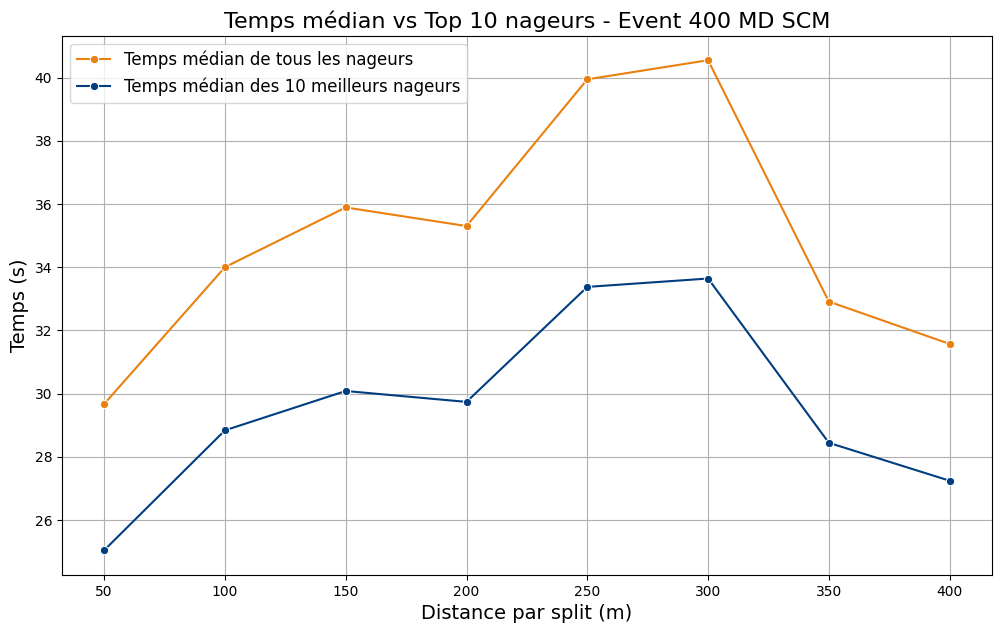

In [ ]:
nom_event = "400 MD SCM"

df_event = df[
    (df['Event'] == nom_event) &
    (df['SwimTimeSeconds'].notna()) &
    (df['swimmer'].apply(len) == 1)
].copy()

split_data = []

for idx, row in df_event.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_splits = pd.DataFrame(split_data)

df_median_splits = df_splits.groupby('split_distance', as_index=False)['split_seconds'].median()

# Top 10 nageurs
df_top10 = df_event.nsmallest(10, 'SwimTimeSeconds')

top10_split_data = []

for idx, row in df_top10.iterrows():
    splits = row['splits']
    if splits:
        for s in splits:
            if s['split_seconds'] is not None:
                dist = int(s['split_distance'].replace(' m',''))
                top10_split_data.append({
                    'split_distance': dist,
                    'split_seconds': s['split_seconds']
                })

df_top10_splits = pd.DataFrame(top10_split_data)

df_top10_median = df_top10_splits.groupby('split_distance', as_index=False)['split_seconds'].median()

plt.figure(figsize=(12,7))

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_median_splits,
    marker='o',
    color="#EA800F",
    label="Temps médian de tous les nageurs"
)

sns.lineplot(
    x='split_distance',
    y='split_seconds',
    data=df_top10_median,
    marker='o',
    color="#003E80",
    label="Temps médian des 10 meilleurs nageurs"
)

plt.xticks(range(
    50,
    max(df_median_splits['split_distance'].max(),
        df_top10_median['split_distance'].max()) + 50,
    50
))

plt.title(f"Temps médian vs Top 10 nageurs - Event {nom_event}", fontsize=16)
plt.xlabel("Distance par split (m)", fontsize=14)
plt.ylabel("Temps (s)", fontsize=14)

plt.grid(True)
plt.legend(fontsize=12)

plt.show()

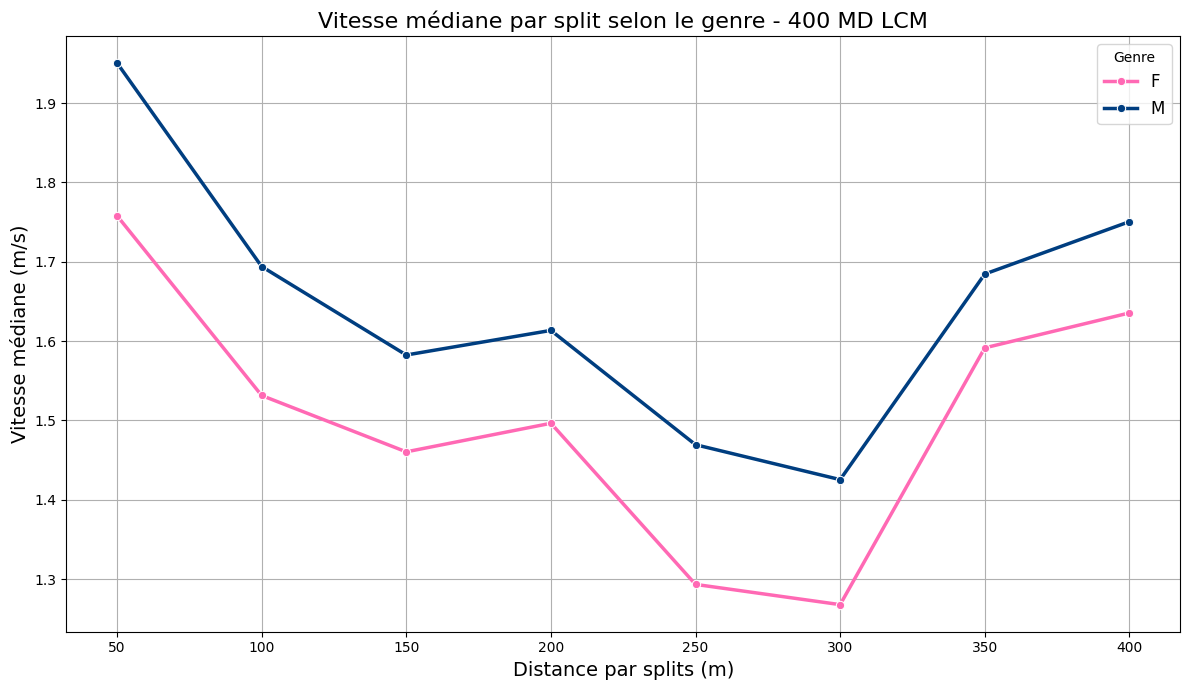

In [13]:
nom_event = "400 MD LCM"
top_n = 10

df_event = df[
    (df["Event"] == nom_event) &
    (df["SwimTimeSeconds"].notna()) &
    (df["swimmer"].apply(lambda x: isinstance(x, list) and len(x) == 1))
].copy()

df_event["swimmer_name"] = df_event["swimmer"].apply(lambda x: x[0]["Name"])
df_event["swimmer_gender"] = df_event["swimmer"].apply(lambda x: x[0]["Gender"])

df_top_men = df_event[df_event["swimmer_gender"] == "M"].nsmallest(top_n, "SwimTimeSeconds")
df_top_women = df_event[df_event["swimmer_gender"] == "F"].nsmallest(top_n, "SwimTimeSeconds")
df_top_all = pd.concat([df_top_men, df_top_women], ignore_index=True)

split_data = []
for _, row in df_top_all.iterrows():
    gender = row["swimmer_gender"]
    splits = row["splits"]

    if isinstance(splits, list):
        for s in splits:
            if not isinstance(s, dict):
                continue
            try:
                dist = int(str(s.get("split_distance")).replace(" m", "").strip())
            except (ValueError, TypeError):
                continue

            split_speed = s.get("split_speed")
            if split_speed is None:
                continue

            try:
                split_speed = float(split_speed)
            except (ValueError, TypeError):
                continue

            split_data.append({
                "gender": gender,
                "split_distance": dist,
                "split_speed": split_speed
            })

df_splits = pd.DataFrame(split_data)

if df_splits.empty:
    print("Aucune donnée de split exploitable.")
else:
    df_med = (
        df_splits
        .groupby(["gender", "split_distance"])["split_speed"]
        .median()
        .reset_index()
    )

    plt.figure(figsize=(12, 7))
    palette_colors = {"M": "#003E80", "F": "#FF69B4"}

    sns.lineplot(
        x="split_distance",
        y="split_speed",
        hue="gender",
        data=df_med,
        marker="o",
        palette=palette_colors,
        linewidth=2.5
    )

    plt.xticks(range(50, int(df_splits["split_distance"].max()) + 50, 50))
    plt.title(f"Vitesse médiane par split selon le genre - {nom_event}", fontsize=16)
    plt.xlabel("Distance par splits (m)", fontsize=14)
    plt.ylabel("Vitesse médiane (m/s)", fontsize=14)
    plt.grid(True)
    plt.legend(title="Genre", fontsize=12)
    plt.tight_layout()
    plt.show()

<h2 style="color:gray; font-size:20px;">Split 2</h2>

In [121]:
nom_event = "400 MD LCM"
gender_target = "M"

mask = (
    (df["Event"] == nom_event)
    & (df["SwimTimeSeconds"].notna())
    & df["swimmer"].apply(
        lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target
    )
    & df["splits"].apply(lambda x: isinstance(x, list) and len(x) > 0)
    & df["splits"].apply(
        lambda s: str(s[0].get("split_distance")).strip() == "100 m"
        if isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict)
        else False
    )
)

nb_perf_valides = mask.sum()

print(
    f"Nombre de performances valides avec premier split = 100 m pour l'event {nom_event} "
    f"et Gender {gender_target} : {nb_perf_valides}"
)

Nombre de performances valides avec premier split = 100 m pour l'event 400 MD LCM et Gender M : 1713


In [122]:
gender_target = "M"

base_mask = (
    (df["SwimTimeSeconds"].notna())
    & df["swimmer"].apply(
        lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target
    )
    & df["splits"].apply(
        lambda s: isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict)
    )
)

df_base = df.loc[base_mask].copy()
total = len(df_base)

if total == 0:
    print("Aucune performance valide dans la base.")
else:
    first_split = df_base["splits"].apply(lambda s: str(s[0].get("split_distance")).strip())

    n_100 = (first_split == "100 m").sum()
    n_50 = (first_split == "50 m").sum()

    pct_100 = (n_100 / total) * 100
    pct_50 = (n_50 / total) * 100

    print(f"Gender : {gender_target}")
    print(f"Total performances valides (base) : {total}")
    print(f"Premier split = 100 m : {n_100} ({pct_100:.2f}%)")
    print(f"Premier split = 50 m  : {n_50} ({pct_50:.2f}%)")

Gender : M
Total performances valides (base) : 263325
Premier split = 100 m : 10573 (4.02%)
Premier split = 50 m  : 252502 (95.89%)


In [ ]:
nom_event = "400 MD LCM"
first_split_target = "400 m"   

mask = (
    (df["Event"] == nom_event)
    & df["splits"].apply(
        lambda s: (
            isinstance(s, list)
            and len(s) > 0
            and isinstance(s[0], dict)
            and str(s[0].get("split_distance")).strip() == first_split_target
        )
    )
)

meets_first_split = (
    df.loc[mask, "Meet"]
      .dropna()
      .astype(str)
      .str.strip()
      .drop_duplicates()
      .sort_values()
      .reset_index(drop=True)
)

print(f"Nombre de meets où le 1er split = {first_split_target} pour {nom_event} : {len(meets_first_split)}")
display(meets_first_split.to_frame(name="Meet"))

df_examples = df.loc[mask, ["Meet", "SwimDate", "Event", "SwimTime", "SwimTimeSeconds", "swimmer", "splits"]].copy()

df_examples["Name"] = df_examples["swimmer"].apply(
    lambda x: x[0].get("Name") if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict) else None
)
df_examples["Gender"] = df_examples["swimmer"].apply(
    lambda x: x[0].get("Gender") if isinstance(x, list) and len(x) > 0 and isinstance(x[0], dict) else None
)

n_examples = 5

print(f"\nExemple(s) de performances (top {n_examples}) :")
display(
    df_examples[["Meet", "SwimDate", "Name", "Gender", "Event", "SwimTime", "SwimTimeSeconds"]]
    .head(n_examples)
)

if len(df_examples) > 0:
    print("\nSplits détaillés du 1er exemple :")
    display(pd.DataFrame(df_examples.iloc[0]["splits"]))
else:
    print("\nAucune performance trouvée pour ce filtre.")

Nombre de meets où le 1er split = 400 m pour 400 MD LCM : 1


,Meet
0,Jeux Olympiques



Exemple(s) de performances (top 5) :


,Meet,SwimDate,Name,Gender,Event,SwimTime,SwimTimeSeconds
30812,Jeux Olympiques,1992-07-31,Bonnet Céline,F,400 MD LCM,04:54.70,294.7



Splits détaillés du 1er exemple :


,split_distance,split_time,split_seconds,split_speed,cumul_seconds,split_time_cumul
0,400 m,04:54.70,294.7,0.17,294.7,4:54.70


In [123]:
nom_event = "400 MD LCM" 

base_mask = (
    (df["Event"] == nom_event)
    & df["splits"].apply(lambda s: isinstance(s, list) and len(s) > 0 and isinstance(s[0], dict))
)

df_base = df.loc[base_mask].copy()
total = len(df_base)

if total == 0:
    print("Aucune performance avec splits dans la base filtrée.")
else:
    first_split = df_base["splits"].apply(lambda s: str(s[0].get("split_distance")).strip())

    n_100 = (first_split == "100 m").sum()
    n_50 = (first_split == "50 m").sum()

    pct_100 = (n_100 / total) * 100
    pct_50 = (n_50 / total) * 100

    print(f"Event considéré : {nom_event}")
    print(f"Total performances (avec au moins 1 split) : {total}")
    print(f"Premier split = 100 m : {n_100} ({pct_100:.2f}%)")
    print(f"Premier split = 50 m  : {n_50} ({pct_50:.2f}%)")

Event considéré : 400 MD LCM
Total performances (avec au moins 1 split) : 24065
Premier split = 100 m : 3311 (13.76%)
Premier split = 50 m  : 20754 (86.24%)


In [12]:
nom_event = "400 MD LCM"
gender_target = "F"

df_event = df[
    (df["Event"] == nom_event)
    & (df["swimmer"].apply(lambda x: isinstance(x, list) and len(x) > 0 and x[0].get("Gender") == gender_target))
].copy()

split_rows = []
for _, row in df_event.iterrows():
    splits = row.get("splits", [])
    if isinstance(splits, list):
        for s in splits:
            split_distance = s.get("split_distance")
            split_speed = s.get("split_speed")

            if split_distance is None or split_speed is None:
                continue

            try:
                dist = int(str(split_distance).replace(" m", "").strip())   
                speed = float(split_speed)
            except (ValueError, TypeError):
                continue

            split_rows.append({
                "split_distance": dist,
                "split_speed": speed
            })

df_splits = pd.DataFrame(split_rows)

if df_splits.empty:
    print("Aucune donnée de split_speed trouvée pour 400 MD LCM / Gender M.")
else:
    stats_splits = (
        df_splits
        .groupby("split_distance", as_index=False)
        .agg(
            moyenne_split_speed=("split_speed", "mean"),
            mediane_split_speed=("split_speed", "median"),
            n=("split_speed", "count")
        )
        .sort_values("split_distance")
    )

    stats_splits["moyenne_split_speed"] = stats_splits["moyenne_split_speed"].round(4)
    stats_splits["mediane_split_speed"] = stats_splits["mediane_split_speed"].round(4)

    display(stats_splits)

,split_distance,moyenne_split_speed,mediane_split_speed,n
0,50,1.5382,1.540,9722
1,100,1.2594,1.326,11317
2,150,1.2768,1.251,9503
3,200,1.1607,1.241,11314
4,250,1.2358,1.143,9523
5,300,1.0898,1.109,11313
6,350,1.4637,1.409,9504
7,400,1.3612,1.441,11320


In [11]:
mask_swimmer_list = df["swimmer"].apply(lambda x: isinstance(x, list) and len(x) > 0)

if mask_swimmer_list.any():
    row = df.loc[mask_swimmer_list, ["Meet", "swimmer"]].iloc[0]
    print("Meet :", row["Meet"])
    print("Swimmer :", row["swimmer"])
else:
    print("Aucune performance avec swimmer sous forme de liste non vide.")

Meet : Phase finale Coupe de France des Départements
Swimmer : [{'Name': 'Caillere Melvyn', 'Gender': 'M', 'Year_of_birth': 2012, 'Age': 13, 'Nationality': 'FRA'}]


In [10]:
mask_plusieurs_swimmers = df["swimmer"].apply(lambda x: isinstance(x, list) and len(x) > 1)
df_multi = df.loc[mask_plusieurs_swimmers].copy()

def meme_gender(swimmers):
    genders = {
        s.get("Gender")
        for s in swimmers
        if isinstance(s, dict) and s.get("Gender") is not None
    }
    return len(genders) == 1

df_multi["meme_gender"] = df_multi["swimmer"].apply(meme_gender)

nb_multi = len(df_multi)
nb_meme_gender = df_multi["meme_gender"].sum()
nb_gender_mixte = nb_multi - nb_meme_gender

pct_meme_gender = (nb_meme_gender / nb_multi * 100) if nb_multi > 0 else 0
pct_mixte = (nb_gender_mixte / nb_multi * 100) if nb_multi > 0 else 0

print(f"Performances avec plusieurs swimmers : {nb_multi}")
print(f"Avec même Gender : {nb_meme_gender} ({pct_meme_gender:.2f}%)")
print(f"Avec Gender mixte / incohérent : {nb_gender_mixte} ({pct_mixte:.2f}%)")

display(df_multi.loc[~df_multi["meme_gender"], ["Meet", "Event", "SwimTime", "swimmer"]].head(10))

Performances avec plusieurs swimmers : 36681
Avec même Gender : 36681 (100.00%)
Avec Gender mixte / incohérent : 0 (0.00%)


,Meet,Event,SwimTime,swimmer


<h1 style="color:rgb(242, 176, 235); font-size:32px;">Pacing en relais</h1>

<h2 style="color:gray; font-size:20px;">Split Speed vs Distance (Relay Events) with Mean Trend Line</h2>

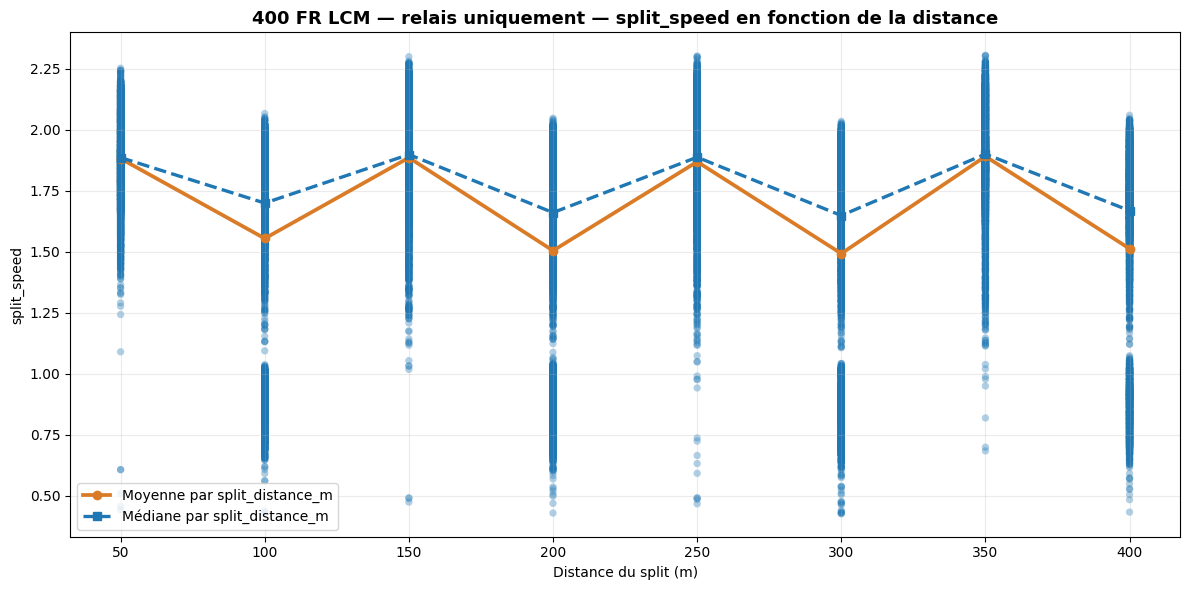

Performances relai retenues : 4679
Points (splits) tracés : 32464


In [9]:
nom_event = "400 FR LCM"  
def parse_dist(x):
    try:
        return int(str(x).replace(" m", "").strip())
    except Exception:
        return None


def is_relay_swimmers(swimmers):
    return isinstance(swimmers, list) and len(swimmers) > 1 and all(
        isinstance(s, dict) for s in swimmers
    )

df_relay = df[
    (df["Event"] == nom_event) & df["swimmer"].apply(is_relay_swimmers)
].copy()

rows = []
for idx, row in df_relay.iterrows():
    splits = row.get("splits", [])
    if not isinstance(splits, list):
        continue
    for s in splits:
        if not isinstance(s, dict):
            continue
        dist = parse_dist(s.get("split_distance"))
        speed = s.get("split_speed")
        if dist is None or speed is None:
            continue
        try:
            speed = float(speed)
        except (TypeError, ValueError):
            continue
        rows.append(
            {
                "perf_idx": idx,
                "split_distance_m": dist,
                "split_speed": speed,
                "nb_swimmers": len(row["swimmer"]),
            }
        )

df_pts = pd.DataFrame(rows)

if df_pts.empty:
    print("Aucun point relai pour cet event (ou splits vides / split_speed manquant).")
else:
    plt.figure(figsize=(12, 6))

    plt.scatter(
        df_pts["split_distance_m"],
        df_pts["split_speed"],
        alpha=0.35,
        s=28,
        edgecolors="none",
    )

    mean_by_dist = (
        df_pts.groupby("split_distance_m", as_index=False)["split_speed"].mean().sort_values("split_distance_m")
    )
    plt.plot(
        mean_by_dist["split_distance_m"],
        mean_by_dist["split_speed"],
        color="#DA7B27",
        linewidth=2.7,
        marker="o",
        label="Moyenne par split_distance_m",
    )

    median_by_dist = (
        df_pts.groupby("split_distance_m", as_index=False)["split_speed"].median().sort_values("split_distance_m")
    )
    plt.plot(
        median_by_dist["split_distance_m"],
        median_by_dist["split_speed"],
        color="#1F77B4",
        linewidth=2.4,
        linestyle="--",
        marker="s",
        label="Médiane par split_distance_m",
    )

    plt.title(f"{nom_event} — relais uniquement — split_speed en fonction de la distance", fontsize=13, weight="bold")
    plt.xlabel("Distance du split (m)")
    plt.ylabel("split_speed")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Performances relai retenues :", len(df_relay))
    print("Points (splits) tracés :", len(df_pts))

<h1 style="color:rgb(242, 176, 235); font-size:32px;">Couloirs de performance (nageur + événement)</h1>


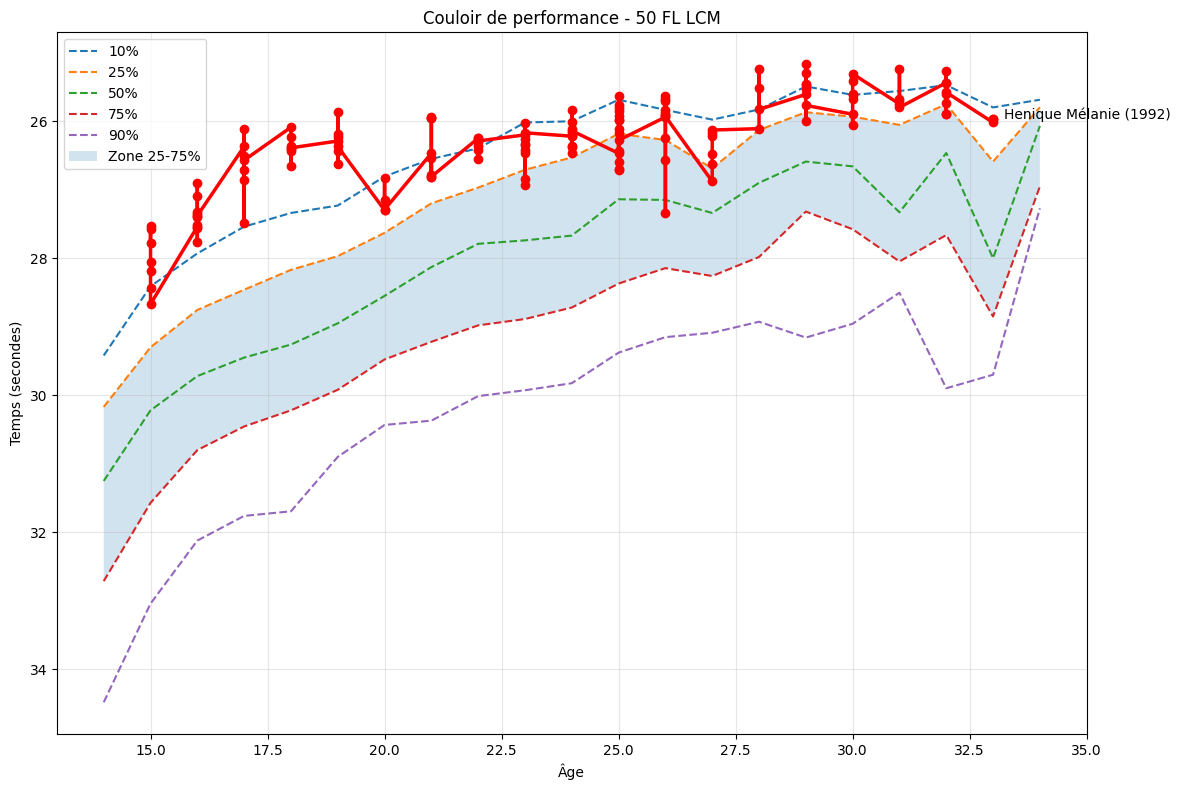

In [7]:
def build_long_swims(df, solo_only=True):
    data = df.copy()

    if solo_only:
        data = data[data["swimmer"].apply(
            lambda x: isinstance(x, list) and len(x) == 1
        )]

    data["swimmer_dict"] = data["swimmer"].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) == 1 else None
    )

    data["Name"] = data["swimmer_dict"].apply(lambda x: x.get("Name") if isinstance(x, dict) else None)
    data["Gender"] = data["swimmer_dict"].apply(lambda x: x.get("Gender") if isinstance(x, dict) else None)
    data["Year_of_birth"] = data["swimmer_dict"].apply(lambda x: x.get("Year_of_birth") if isinstance(x, dict) else None)
    data["Age_json"] = data["swimmer_dict"].apply(lambda x: x.get("Age") if isinstance(x, dict) else None)

    data["SwimYear"] = pd.to_datetime(data["SwimDate"], errors="coerce").dt.year

    data["Age_swim"] = data["Age_json"]

    mask = (
        data["Age_swim"].isna() &
        data["Year_of_birth"].notna() &
        data["SwimYear"].notna()
    )

    data.loc[mask, "Age_swim"] = (
        data.loc[mask, "SwimYear"] - data.loc[mask, "Year_of_birth"]
    )

    data["Age_swim"] = pd.to_numeric(data["Age_swim"], errors="coerce").astype("Int64")

    return data

def performance_corridor_plot_time(
    df,
    nom_event,
    nom_nageur,
    year_of_birth,
    age_min=14,
    age_max=35,
    solo_only=True,
    min_points=5,
    figsize=(12, 8),
):

    long_df = build_long_swims(df, solo_only=solo_only)

    long_df = long_df[
        (long_df["Event"] == nom_event) &
        (long_df["SwimTimeSeconds"].notna()) &
        (long_df["Name"].notna()) &
        (long_df["Gender"].notna()) &
        (long_df["Age_swim"].notna()) &
        (long_df["Year_of_birth"].notna())
    ].copy()

    if long_df.empty:
        print(f"Aucune donnée pour {nom_event}")
        return

    target_name = nom_nageur.strip().lower()

    swimmer_data = long_df[
        (long_df["Name"].str.strip().str.lower() == target_name) &
        (long_df["Year_of_birth"] == year_of_birth)
    ]

    if swimmer_data.empty:
        print(f"Nageur introuvable : {nom_nageur} ({year_of_birth})")
        print("Exemples :", long_df["Name"].drop_duplicates().head(10).tolist())
        return

    gender = swimmer_data["Gender"].mode().iloc[0]
    long_df = long_df[long_df["Gender"] == gender]

    swimmer_name = swimmer_data.iloc[0]["Name"]
    swimmer_yob = swimmer_data.iloc[0]["Year_of_birth"]

    percentiles = [10, 25, 50, 75, 90]

    grouped = long_df.groupby("Age_swim")["SwimTimeSeconds"].agg(list)

    grouped = grouped.apply(
        lambda x: x if len(x) >= min_points else np.nan
    ).dropna()

    df_percentiles = pd.DataFrame({
        f"p{p}": grouped.apply(lambda x: np.percentile(x, p))
        for p in percentiles
    })

    df_percentiles = df_percentiles.loc[
        (df_percentiles.index >= age_min) &
        (df_percentiles.index <= age_max)
    ]

    df_swimmer = long_df[
        (long_df["Name"] == swimmer_name) &
        (long_df["Year_of_birth"] == swimmer_yob)
    ].sort_values("Age_swim")

    fig, ax = plt.subplots(figsize=figsize)

    for p in percentiles:
        ax.plot(
            df_percentiles.index,
            df_percentiles[f"p{p}"],
            linestyle="--",
            label=f"{p}%"
        )

    ax.fill_between(
        df_percentiles.index,
        df_percentiles["p25"],
        df_percentiles["p75"],
        alpha=0.2,
        label="Zone 25-75%"
    )

    ax.plot(
        df_swimmer["Age_swim"],
        df_swimmer["SwimTimeSeconds"],
        color="red",
        linewidth=2.5,
        marker="o"
    )

    if not df_swimmer.empty:
        last = df_swimmer.iloc[-1]
        ax.scatter(last["Age_swim"], last["SwimTimeSeconds"], color="red")
        ax.annotate(
            f"{swimmer_name} ({swimmer_yob})",
            (last["Age_swim"], last["SwimTimeSeconds"]),
            xytext=(8, 0),
            textcoords="offset points"
        )

    ax.invert_yaxis()
    ax.set_xlabel("Âge")
    ax.set_ylabel("Temps (secondes)")
    ax.set_title(f"Couloir de performance - {nom_event}")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    return fig, ax

performance_corridor_plot_time(
    df,
    nom_event="50 FL LCM",
    nom_nageur="Henique Mélanie",
    year_of_birth=1992
)

plt.show()